In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from termcolor import cprint
from pathlib import Path
import pandas as pd
import os
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator # Para que el eje X solo muestre números enteros
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator
import results_analysis_utils as rutils

# Configuración estética para artículos científicos (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300 # Alta resolución
plt.rcParams['savefig.dpi'] = 300

# Parámetros Globales
ROOT_DIR = "//home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/"
ASPECT_RATIO_THR = 3.0
ANGLE_THR = 20.0
gt = 31.5
df=[]

ROOT_DIR
folder_code =ROOT_DIR.split("/")[-2]
folder_code

'2024_11_12'

In [2]:
# IN CASE WE WANT TO REGENERATE THE CSVS

# all_dfs = []
# print(f"Buscando datos RAW en: {ROOT_DIR}")

# for root, dirs, files in os.walk(ROOT_DIR):
#     # Pode de carpetas pesadas (por si acaso has copiado la estructura entera)
#     dirs[:] = [d for d in dirs if not d.startswith("frame_") and d not in {"_inferred", "debug"}]
    
#     # Si estamos en la carpeta results, buscamos archivos que terminen en _raw.csv
#     if os.path.basename(root) == "corrected_results":
#         for file in files:
#             if file.endswith("_raw.csv"):
#                 filepath = Path(root) / file
#                 print(filepath)
#                 try:
#                     df = pd.read_csv(filepath)
#                     if not df.empty:
#                         # Podemos extraer el código directamente del nombre del archivo que creamos:
#                         # Ej: "13_44_55_compressed_raw.csv" -> "13_44_55_compressed"
#                         folder_code = file.replace("_raw.csv", "")
                        
#                         df.insert(0, 'source_folder', str(folder_code))
#                         all_dfs.append(df)
#                 except Exception as e:
#                     print(f"Error en {filepath}: {e}")

# # MACRO-DATAFRAME
# if all_dfs:
#     df_raw = pd.concat(all_dfs, ignore_index=True)

#     # Forzar tipos booleanos y numéricos para evitar errores de Pandas
#     bool_cols = ['is_3D_complete', 'in_image_borders', 'does_overlap', 'is_front_fish']
#     for col in bool_cols:
#         if col in df_raw.columns: df_raw[col] = df_raw[col].astype(bool)
        
#     num_cols = ['filtered_length', 'raw_length', 'aspect_ratio', 'elevation_deg', 'gt']
#     for col in num_cols:
#         if col in df_raw.columns: df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

#     print(f"✅ Cargadas {len(df_raw)} detecciones individuales de {len(all_dfs)} archivos diferentes.")
# else:
#     print("⚠️ No se encontró ningún archivo que termine en '_raw.csv'")
#     df_raw = pd.DataFrame() # Creamos vacío para que no pete la celda


# print(df.describe())

# df_raw.head()

# --- GUARDAR EL CSV FINAL ---

# out_filename = folder_code +"_all_raw_aggregated.csv"

# df_raw.to_csv(out_filename, index=False)
# print(f"💾 Macro-Dataframe guardado con éxito en:\n   -> {out_filename}")

In [3]:
# LOAD DF:
day_code ="2024_11_12"

csv_path= "/home/slimbook/fish_sizing/ARTICLE/DATASET_1/2024_11_12/2024_11_12_ALL_raw_aggregated.csv"

df_raw_agg = pd.read_csv(csv_path)

# Recalculate failure reason if desired:
df_raw_agg = rutils.assign_failure_reasons(df_raw_agg, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)


display(df_raw_agg.head())
print("SUMMARY")
display(df_raw_agg.describe())



,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,...,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,especie_gt,failure_reason,unique_track,scenario
0,2024_11_12,10_44_11_0,10_44_11_0,frame_1,0,255,-1,1,False,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,aspect_ratio_fail,2024_11_12/10_44_11_0/-1,single_fish
1,2024_11_12,10_44_11_0,10_44_11_0,frame_9,0,255,-1,1,False,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,other,2024_11_12/10_44_11_0/-1,single_fish
2,2024_11_12,10_44_11_0,10_44_11_0,frame_12,0,255,-1,0,True,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_44_11_0/-1,single_fish
3,2024_11_12,10_44_11_0,10_44_11_0,frame_13,0,255,3,0,True,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_44_11_0/3,single_fish
4,2024_11_12,10_44_11_0,10_44_11_0,frame_15,0,255,3,0,True,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_44_11_0/3,single_fish


SUMMARY


,class_name,object_id,track_id,is_3D_complete,aspect_ratio,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
count,2170.0,2170.000000,2170.000000,2170.000000,2170.000000,908.000000,908.000000,908.000000,908.000000,908.000000,2170.0,908.000000,902.000000,908.000000
mean,0.0,251.463594,20.639631,0.891705,3.518527,5.929135,20.457837,0.359882,0.292666,0.300785,31.5,3.171767,7.359181,1.368235
std,0.0,21.213134,16.364427,0.310824,1.128983,30.683125,67.272349,0.861701,0.114226,0.059226,0.0,11.198139,12.634033,0.436891
min,0.0,85.000000,-1.000000,0.000000,1.017788,-44.036129,-179.726320,-1.000000,-1.000000,0.065689,31.5,0.003360,0.010665,0.688009
25%,0.0,255.000000,6.000000,1.000000,2.873239,-17.844211,-8.905959,0.290583,0.294421,0.288399,31.5,0.842977,2.643067,1.037405
50%,0.0,255.000000,16.000000,1.000000,3.537750,-0.376438,2.822817,0.312523,0.302373,0.297606,31.5,1.401118,4.400680,1.343002
75%,0.0,255.000000,38.000000,1.000000,4.120878,27.458975,19.756821,0.711113,0.307925,0.305451,31.5,2.235596,6.975998,1.624116
max,0.0,255.000000,72.000000,1.000000,12.449745,82.399932,179.475980,3.031414,0.895060,1.010889,31.5,131.500000,184.146103,2.956499


,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,...,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,especie_gt,failure_reason,unique_track,scenario
0,2024_11_12,10_44_11_0,10_44_11_0,frame_1,0,255,-1,1,False,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,aspect_ratio_fail,2024_11_12/10_44_11_0/-1,single_fish
1,2024_11_12,10_44_11_0,10_44_11_0,frame_9,0,255,-1,1,False,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,other,2024_11_12/10_44_11_0/-1,single_fish
2,2024_11_12,10_44_11_0,10_44_11_0,frame_12,0,255,-1,0,True,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_44_11_0/-1,single_fish
3,2024_11_12,10_44_11_0,10_44_11_0,frame_13,0,255,3,0,True,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_44_11_0/3,single_fish
4,2024_11_12,10_44_11_0,10_44_11_0,frame_15,0,255,3,0,True,False,...,NaN,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_44_11_0/3,single_fish


SUMMARY RAW DATA


,class_name,object_id,track_id,is_3D_complete,aspect_ratio,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
count,2170.0,2170.000000,2170.000000,2170.000000,2170.000000,908.000000,908.000000,908.000000,908.000000,908.000000,2170.0,908.000000,902.000000,908.000000
mean,0.0,251.463594,20.639631,0.891705,3.518527,5.929135,20.457837,0.359882,0.292666,0.300785,31.5,3.171767,7.359181,1.368235
std,0.0,21.213134,16.364427,0.310824,1.128983,30.683125,67.272349,0.861701,0.114226,0.059226,0.0,11.198139,12.634033,0.436891
min,0.0,85.000000,-1.000000,0.000000,1.017788,-44.036129,-179.726320,-1.000000,-1.000000,0.065689,31.5,0.003360,0.010665,0.688009
25%,0.0,255.000000,6.000000,1.000000,2.873239,-17.844211,-8.905959,0.290583,0.294421,0.288399,31.5,0.842977,2.643067,1.037405
50%,0.0,255.000000,16.000000,1.000000,3.537750,-0.376438,2.822817,0.312523,0.302373,0.297606,31.5,1.401118,4.400680,1.343002
75%,0.0,255.000000,38.000000,1.000000,4.120878,27.458975,19.756821,0.711113,0.307925,0.305451,31.5,2.235596,6.975998,1.624116
max,0.0,255.000000,72.000000,1.000000,12.449745,82.399932,179.475980,3.031414,0.895060,1.010889,31.5,131.500000,184.146103,2.956499


✅ FINAL RESULT: 21 independent FISH (tracks) successfully aggregated.
📊 Success Rate: 16.54%
💾 Guardado df_filtered en: /home/slimbook/fish_sizing/ARTICLE/DATASET_1/2024_11_12/2024_11_12_ALL_raw_aggregated_FILTERED.csv


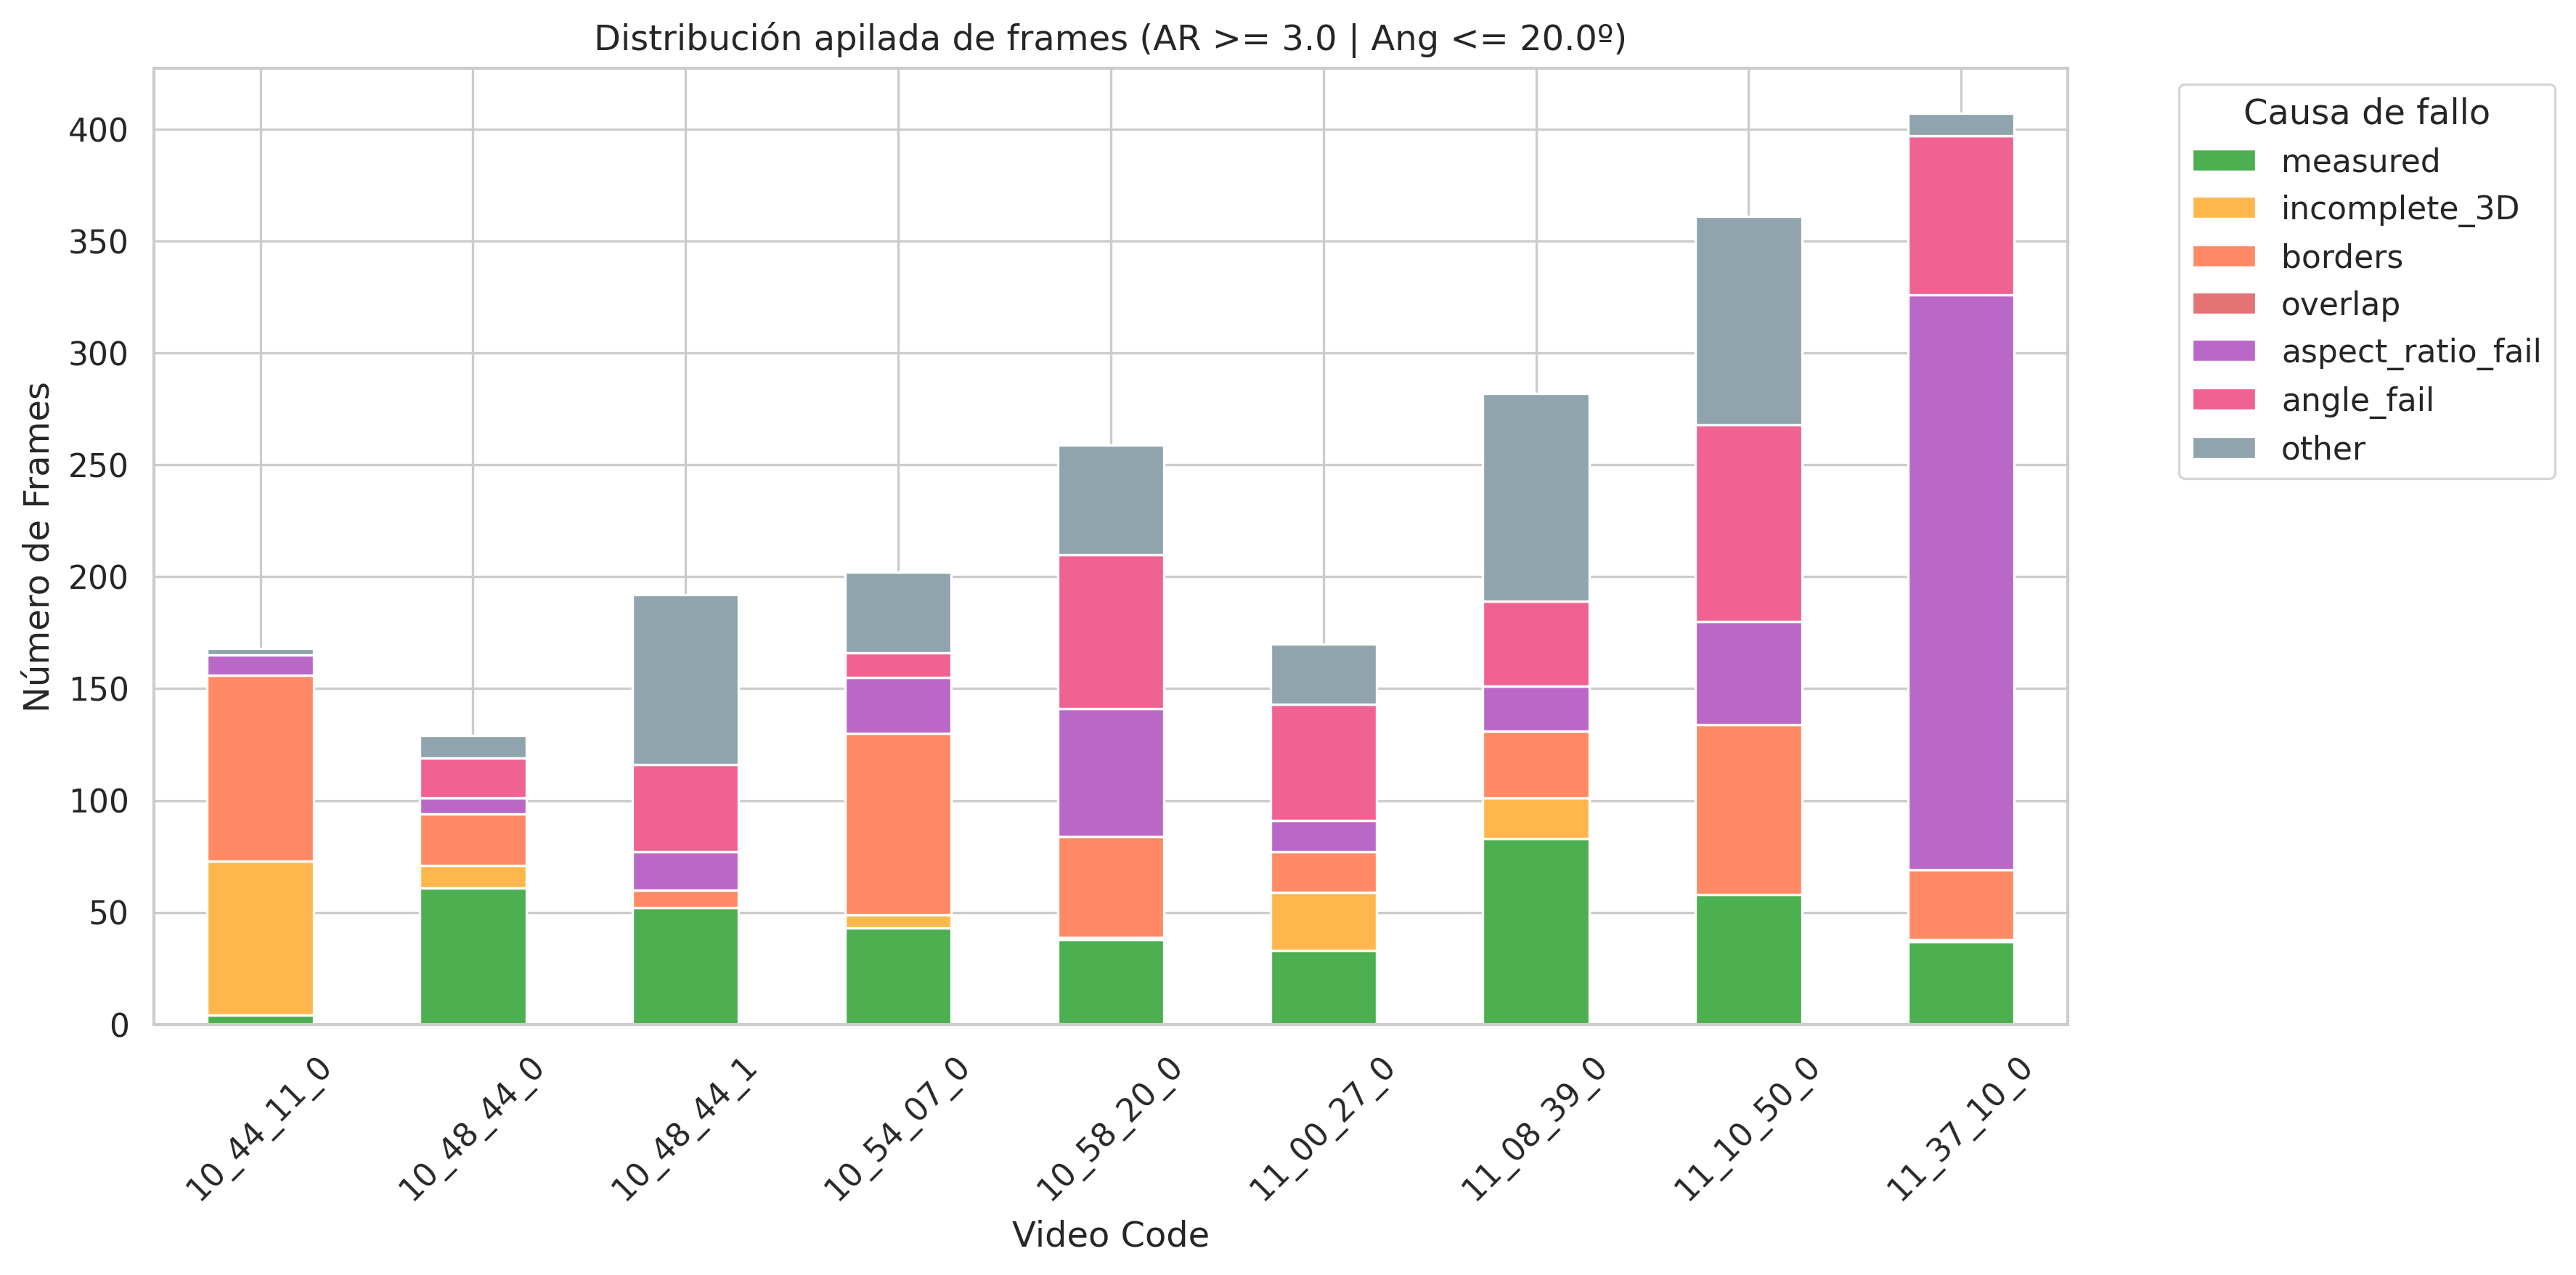

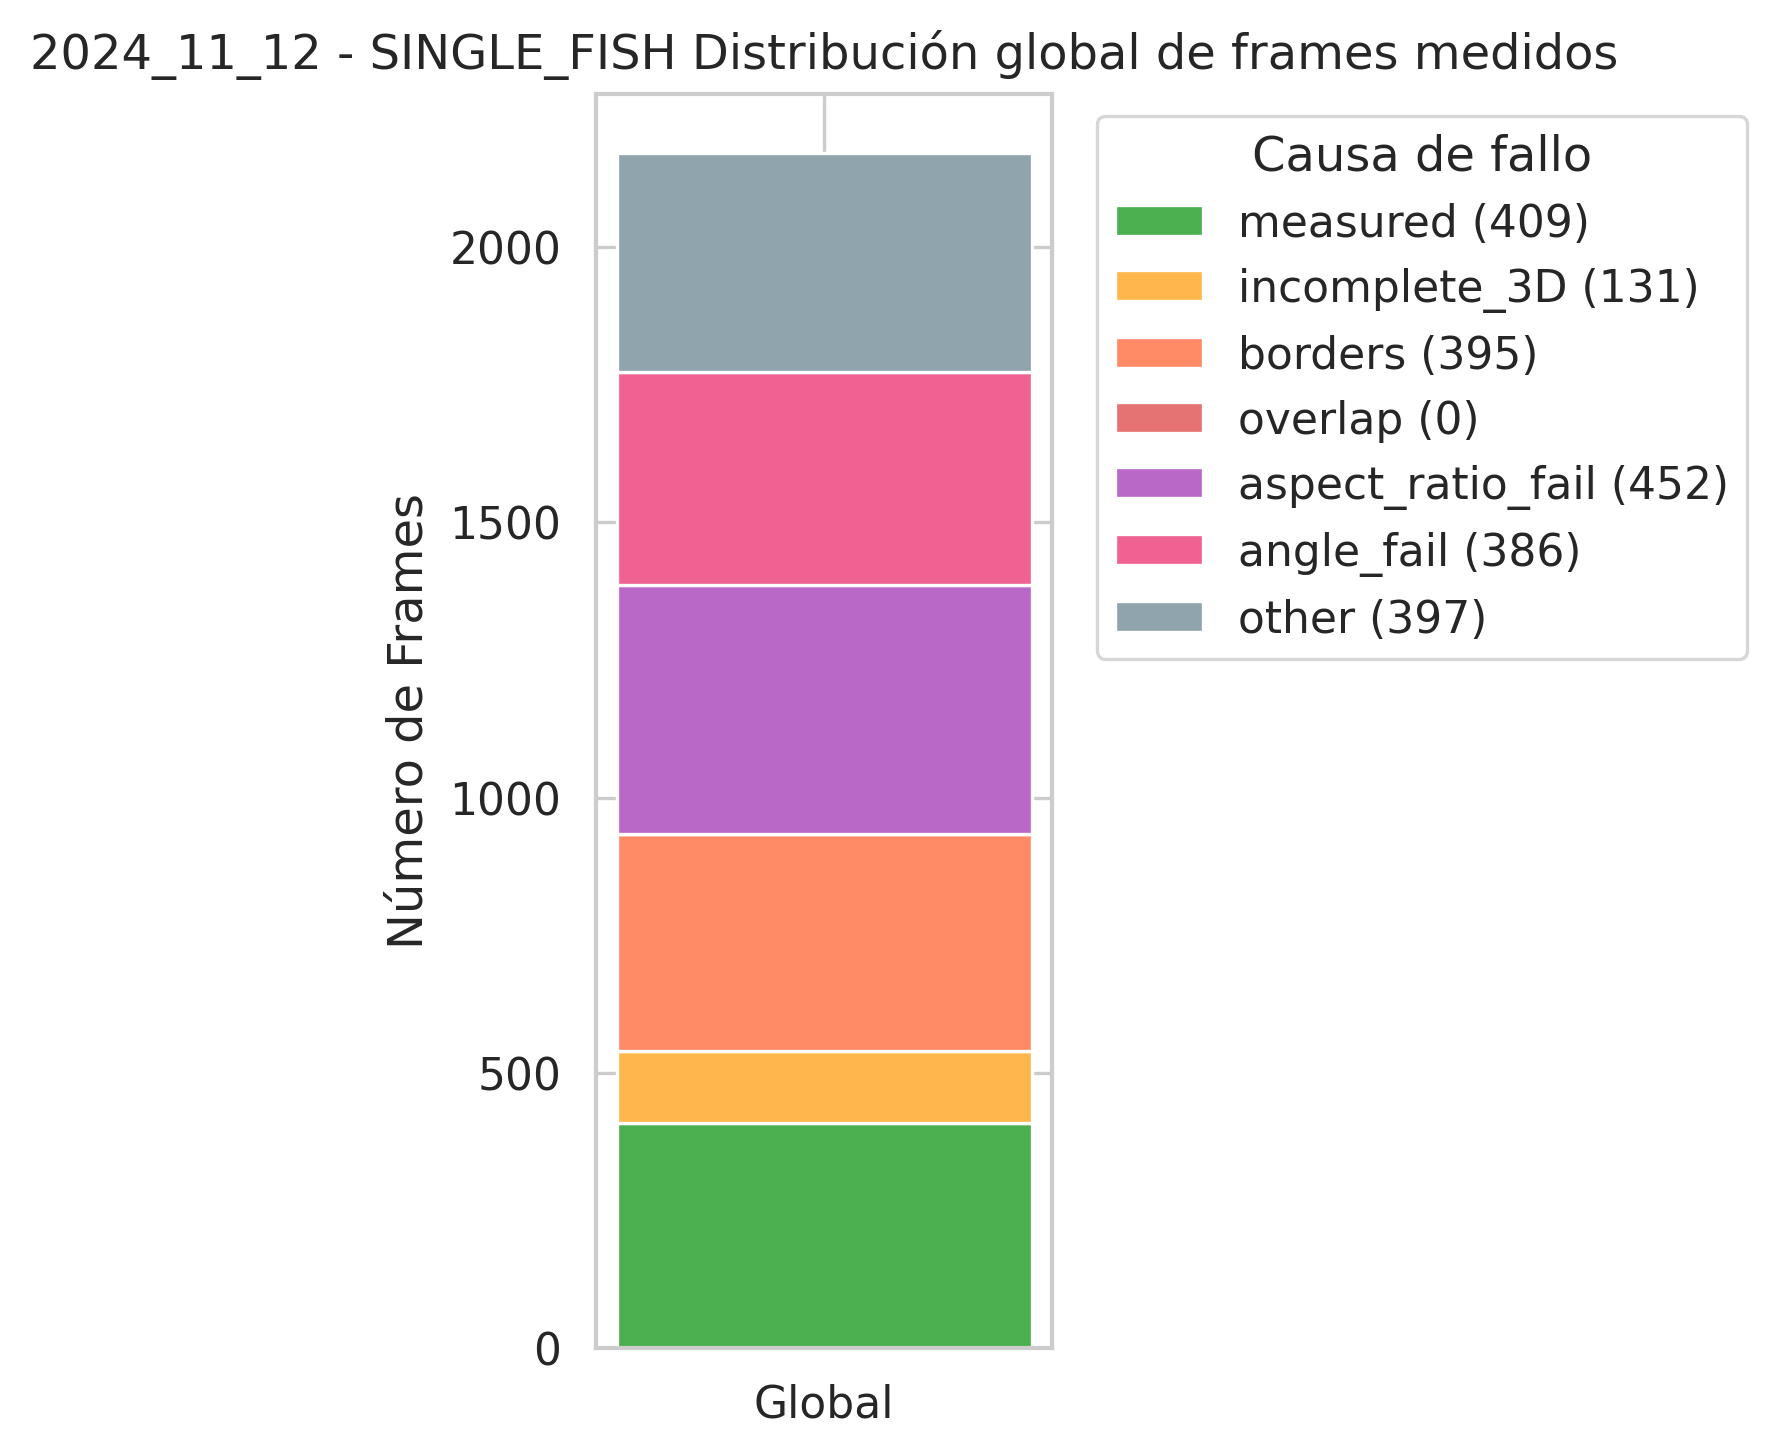


📊 TABLA 1: Distribución Global de Frames


,Causa de Fallo,Cantidad,Porcentaje (%)
0,measured,409,18.85
1,incomplete_3D,131,6.04
2,borders,395,18.20
3,overlap,0,0.00
4,aspect_ratio_fail,452,20.83
5,angle_fail,386,17.79
6,other,397,18.29


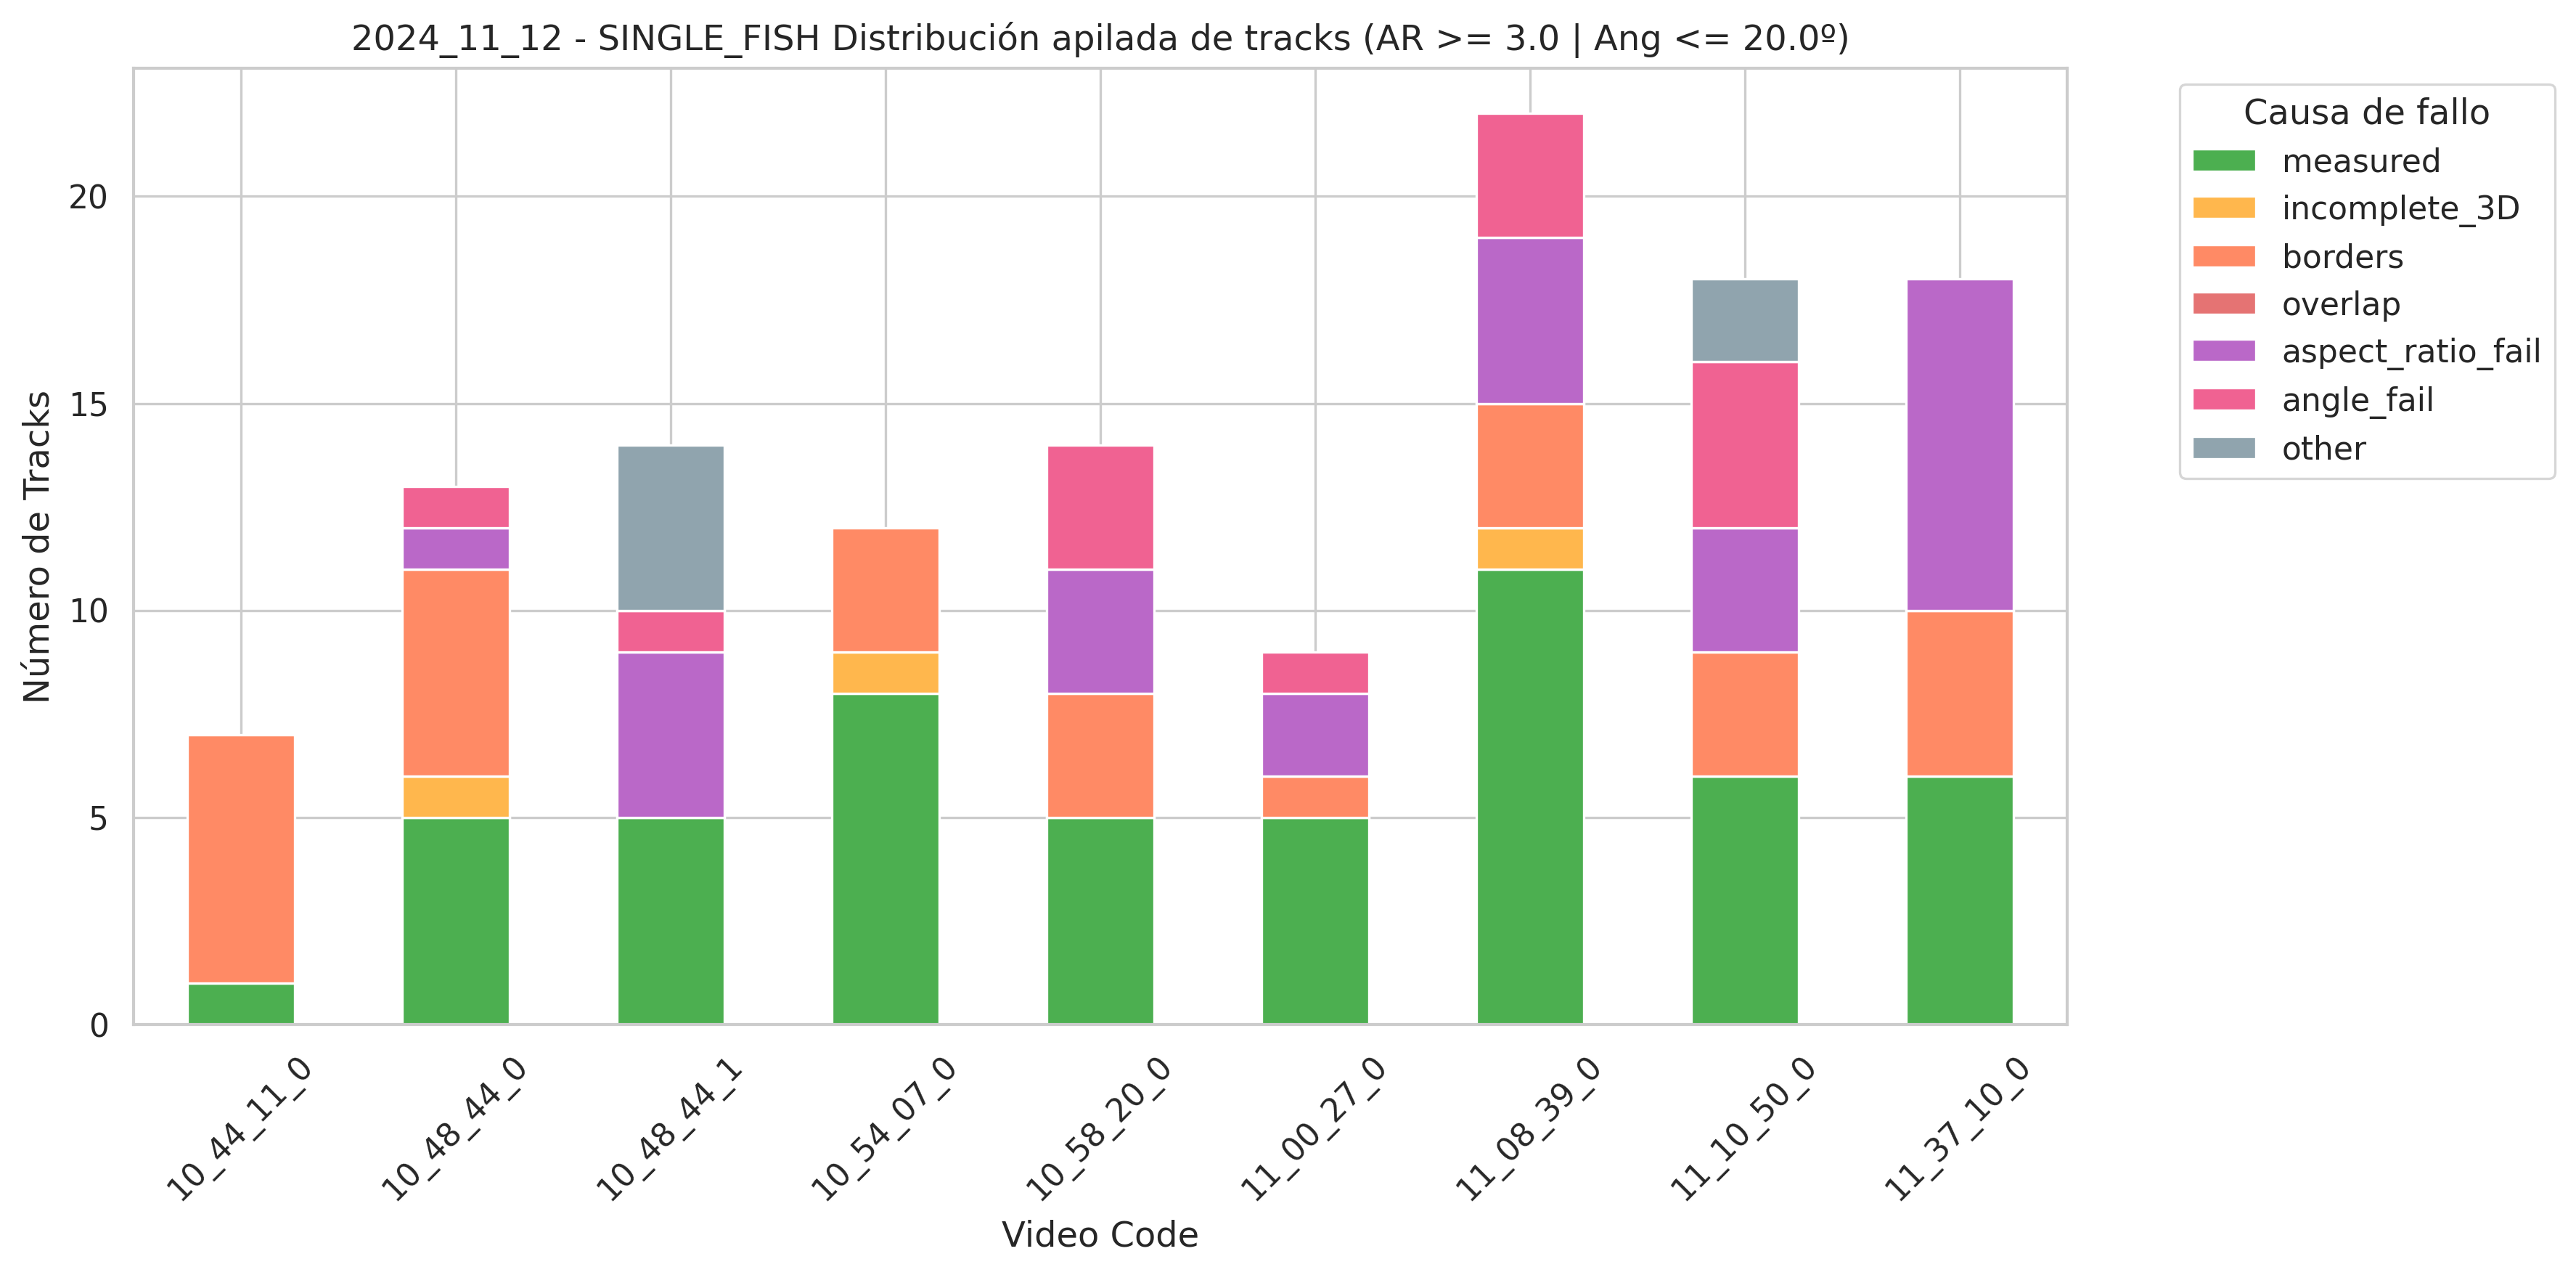

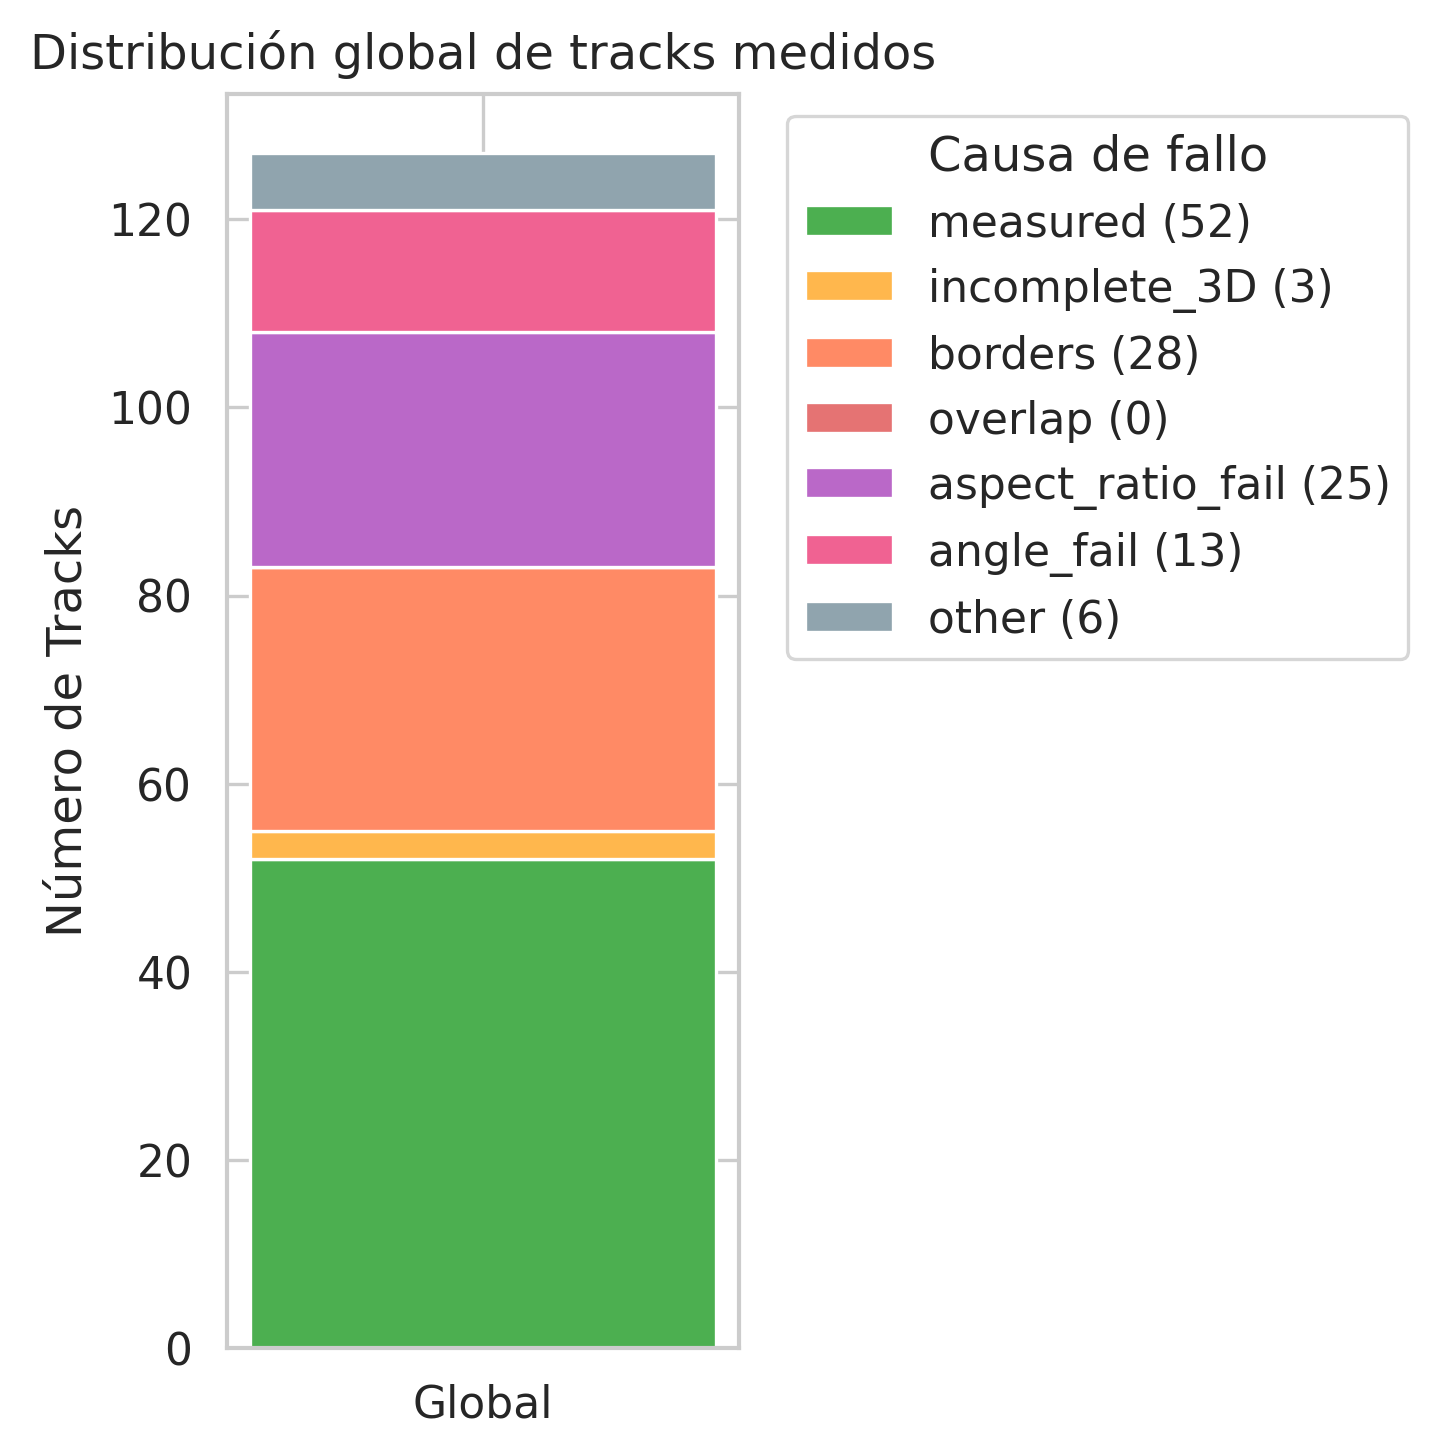


📊 TABLA 1: Distribución Global de Tracks


,Causa de Fallo,Cantidad,Porcentaje (%)
0,measured,52,40.94
1,incomplete_3D,3,2.36
2,borders,28,22.05
3,overlap,0,0.00
4,aspect_ratio_fail,25,19.69
5,angle_fail,13,10.24
6,other,6,4.72



📊 TABLA 2: Desglose por Vídeo


track_failure_reason,measured,incomplete_3D,borders,overlap,aspect_ratio_fail,angle_fail,other
source_folder,,,,,,,
10_44_11_0,1,0,6,0,0,0,0
10_48_44_0,5,1,5,0,1,1,0
10_48_44_1,5,0,0,0,4,1,4
10_54_07_0,8,1,3,0,0,0,0
10_58_20_0,5,0,3,0,3,3,0
11_00_27_0,5,0,1,0,2,1,0
11_08_39_0,11,1,3,0,4,3,0
11_10_50_0,6,0,3,0,3,4,2
11_37_10_0,6,0,4,0,8,0,0


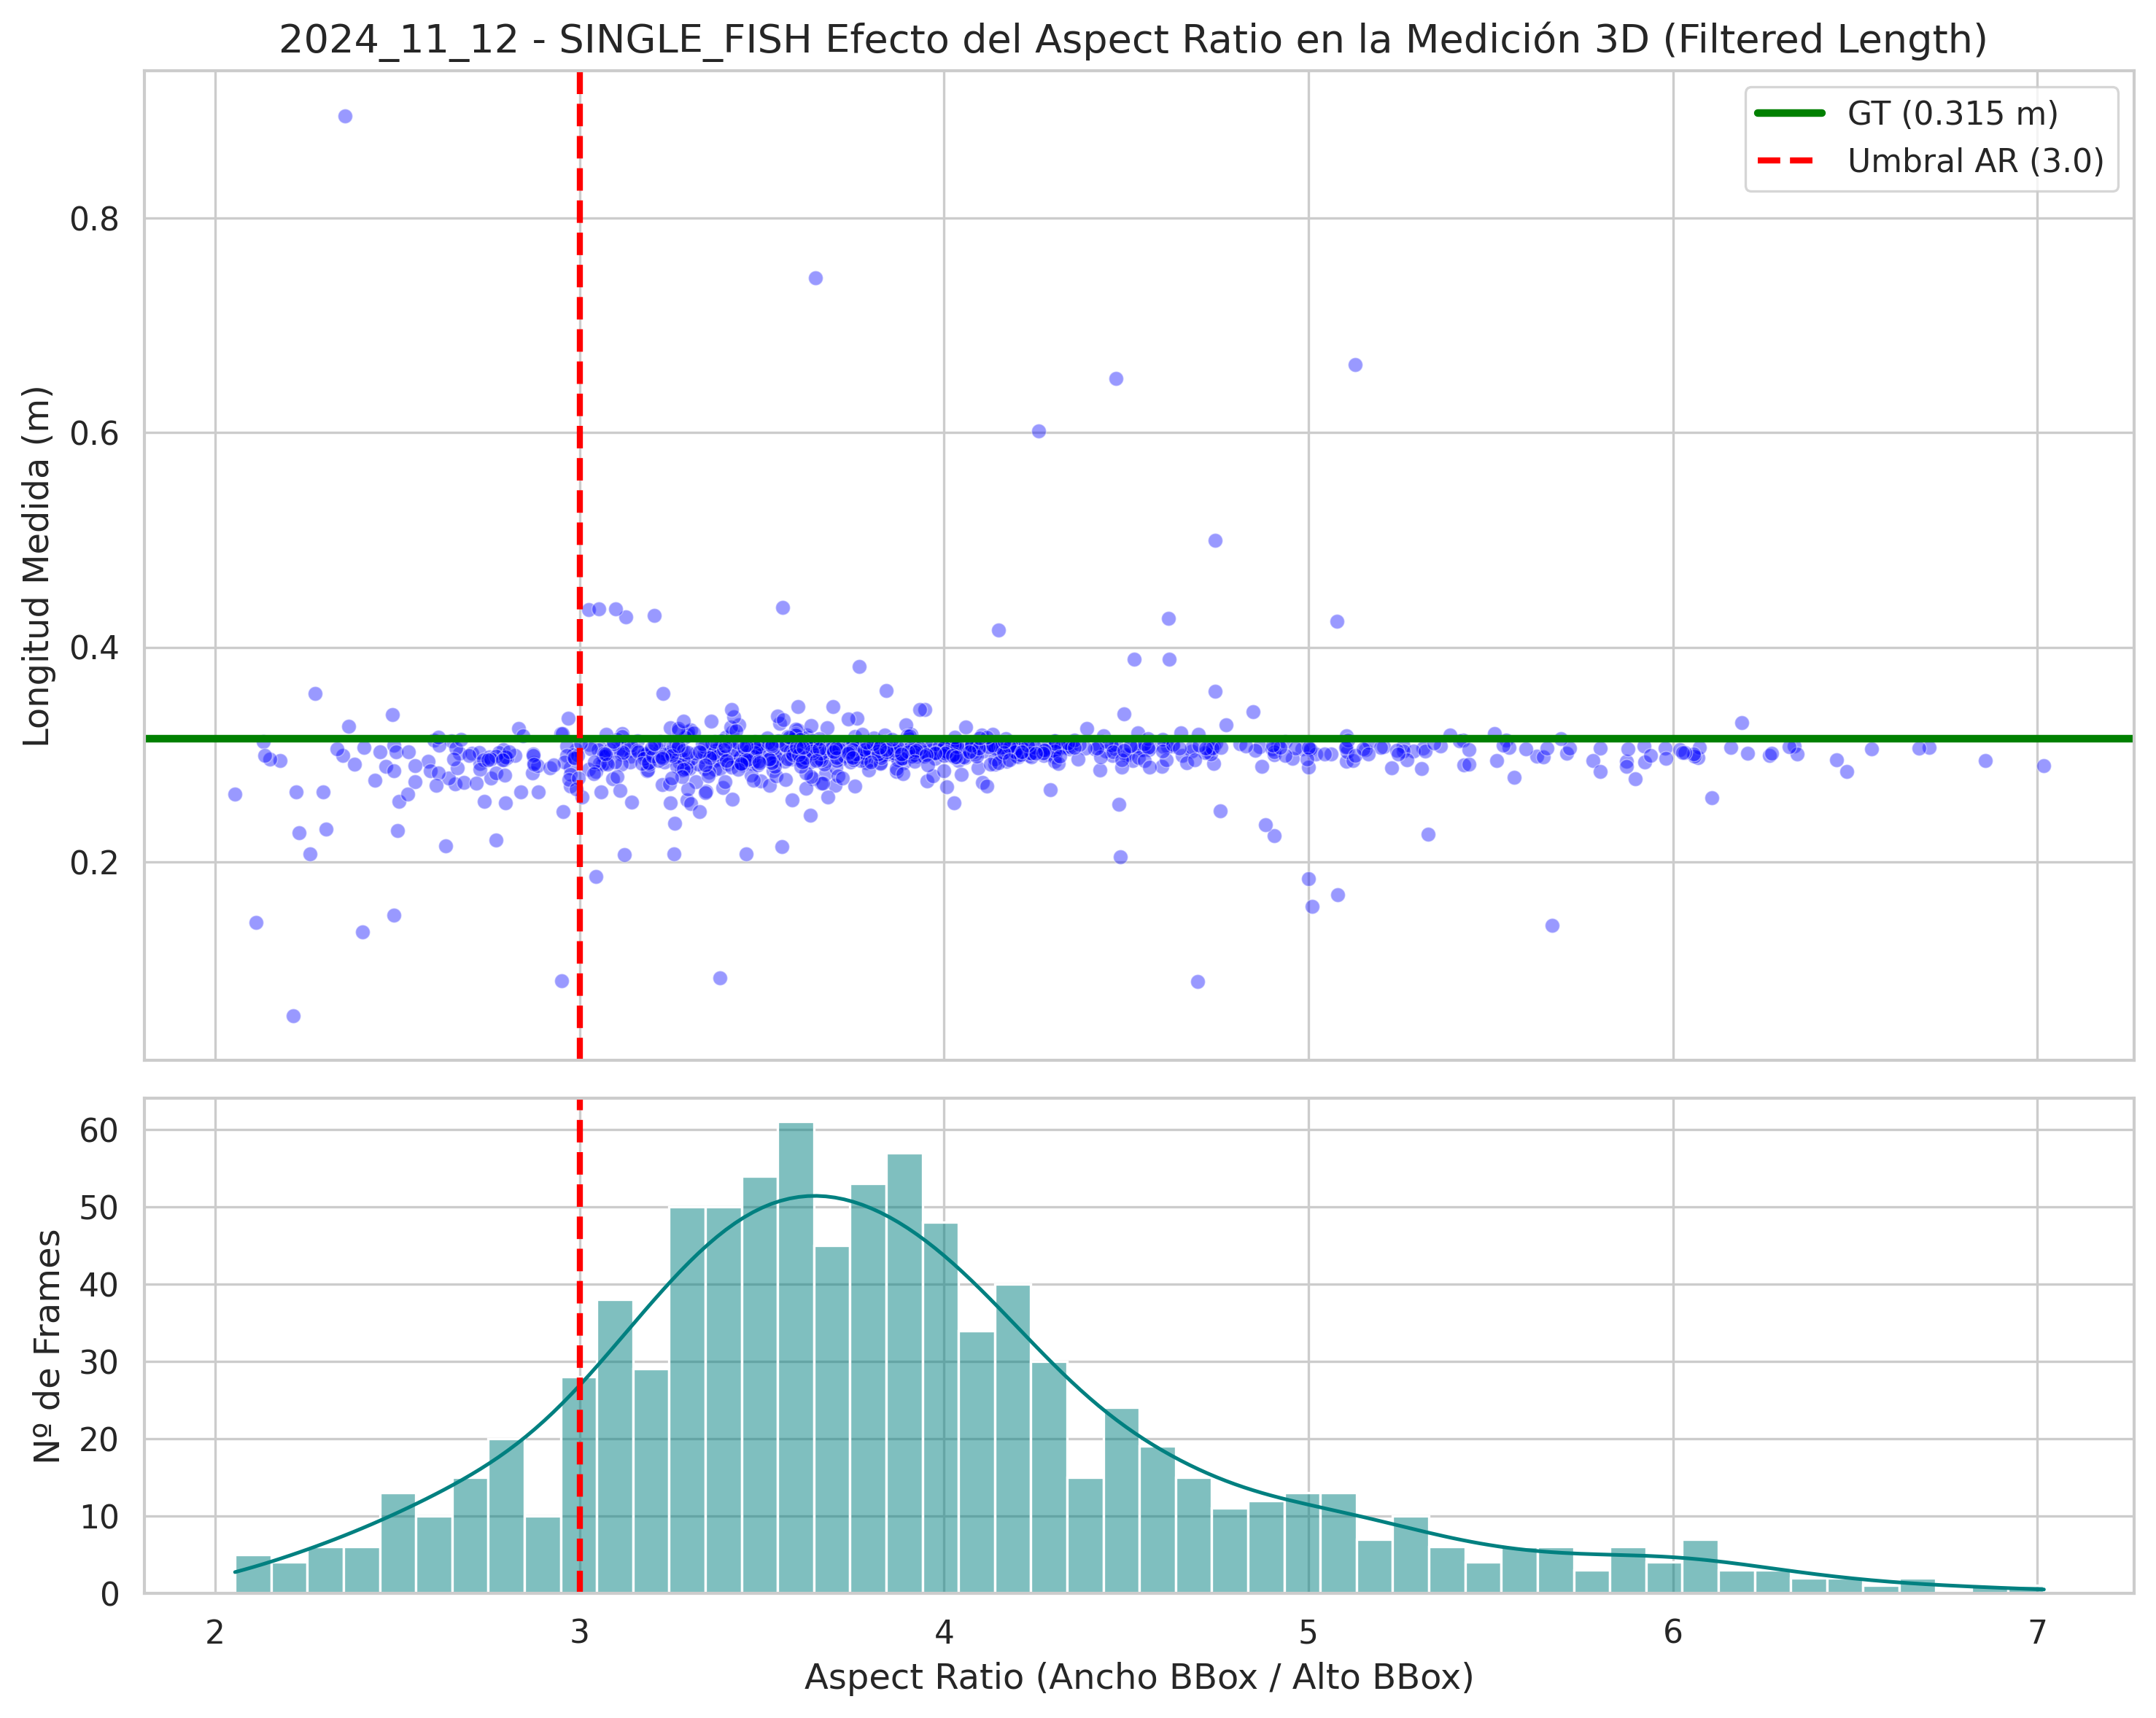

ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN without filters)             |  1.39 ± 2.52 cm |     902 frames |    41 tracks
1. + Filter: No Borders                       |  1.39 ± 2.52 cm |     902 frames |    41 tracks
2. + Filter: No Overlap                       |  1.39 ± 2.52 cm |     902 frames |    41 tracks
3. + Filter: is_3D_complete                   |  1.39 ± 2.52 cm |     902 frames |    41 tracks
4. + Filter: Aspect Ratio >= 3.0              |  1.18 ± 1.98 cm |     795 frames |    37 tracks
5. + Filter: Z-Angle <= 20.0º                 |  0.62 ± 0.43 cm |     409 frames |    21 tracks


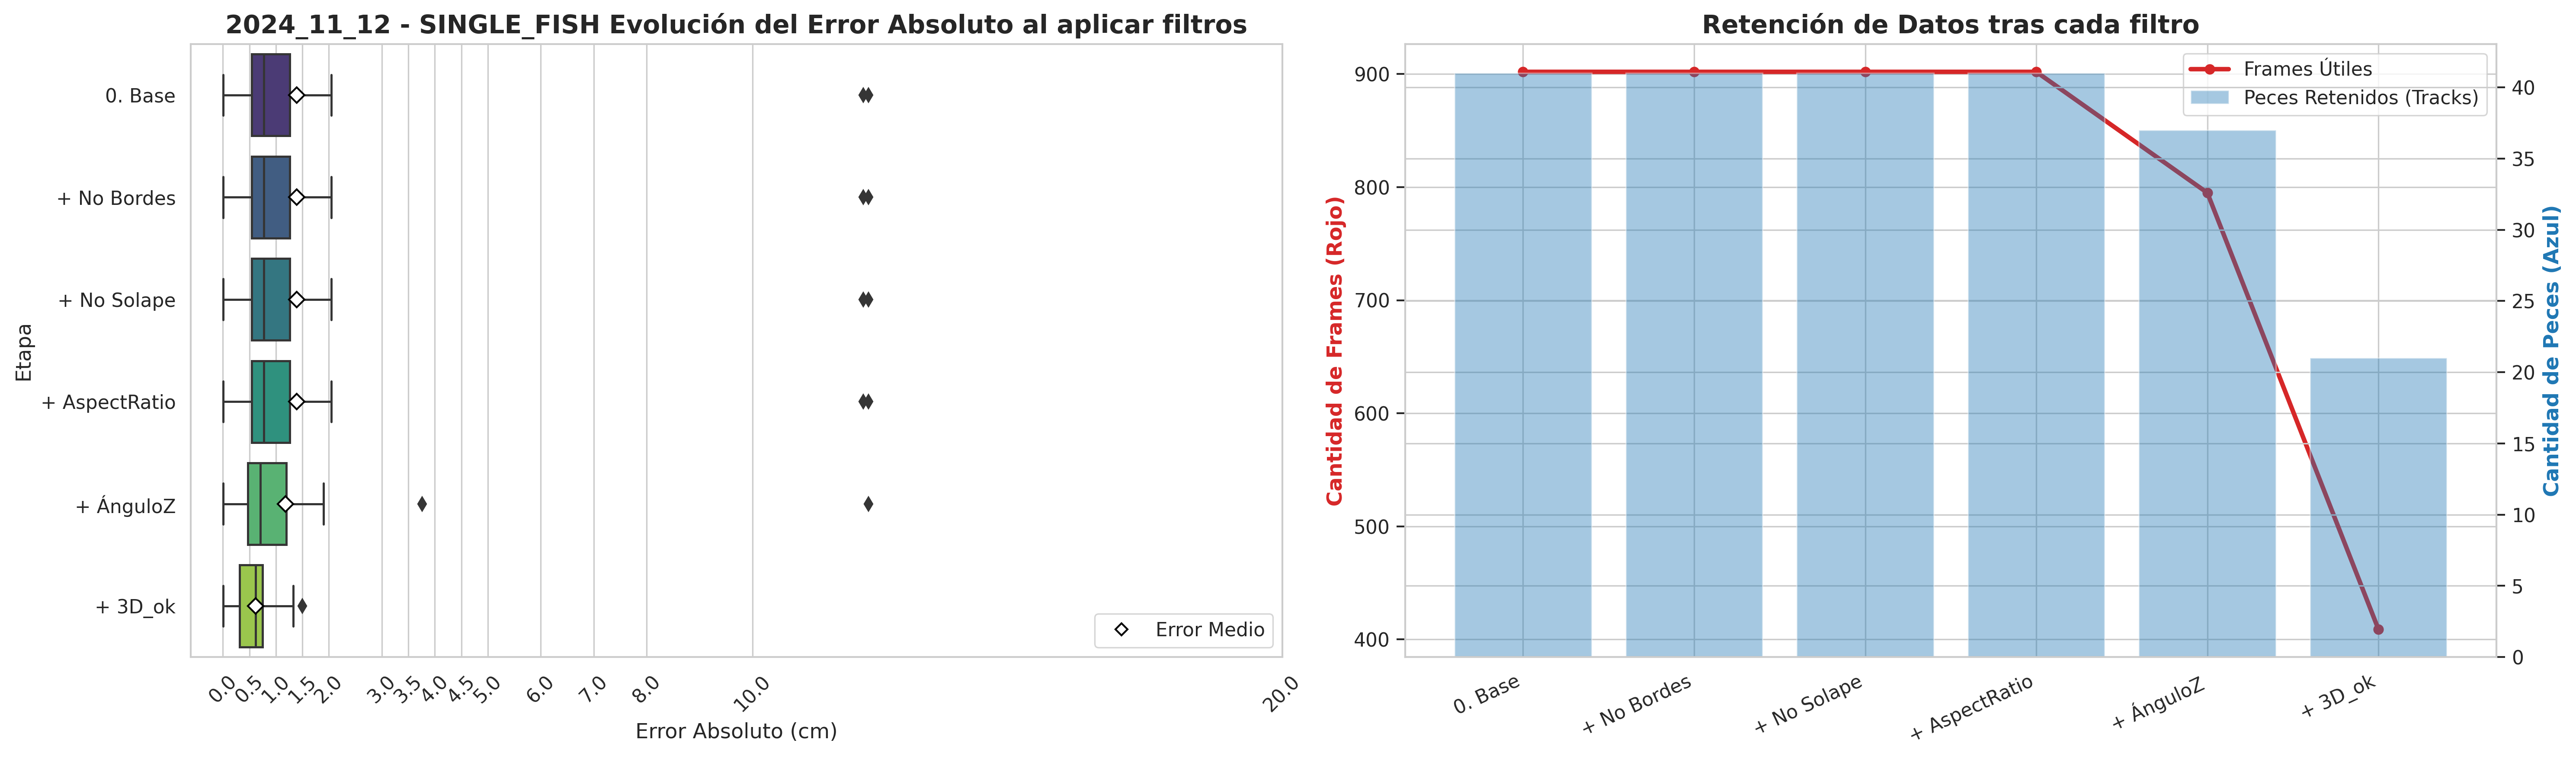

Pipeline Stages Dictionary:


Evaluating Angles: 100%|██████████| 6/6 [00:01<00:00,  4.40it/s]


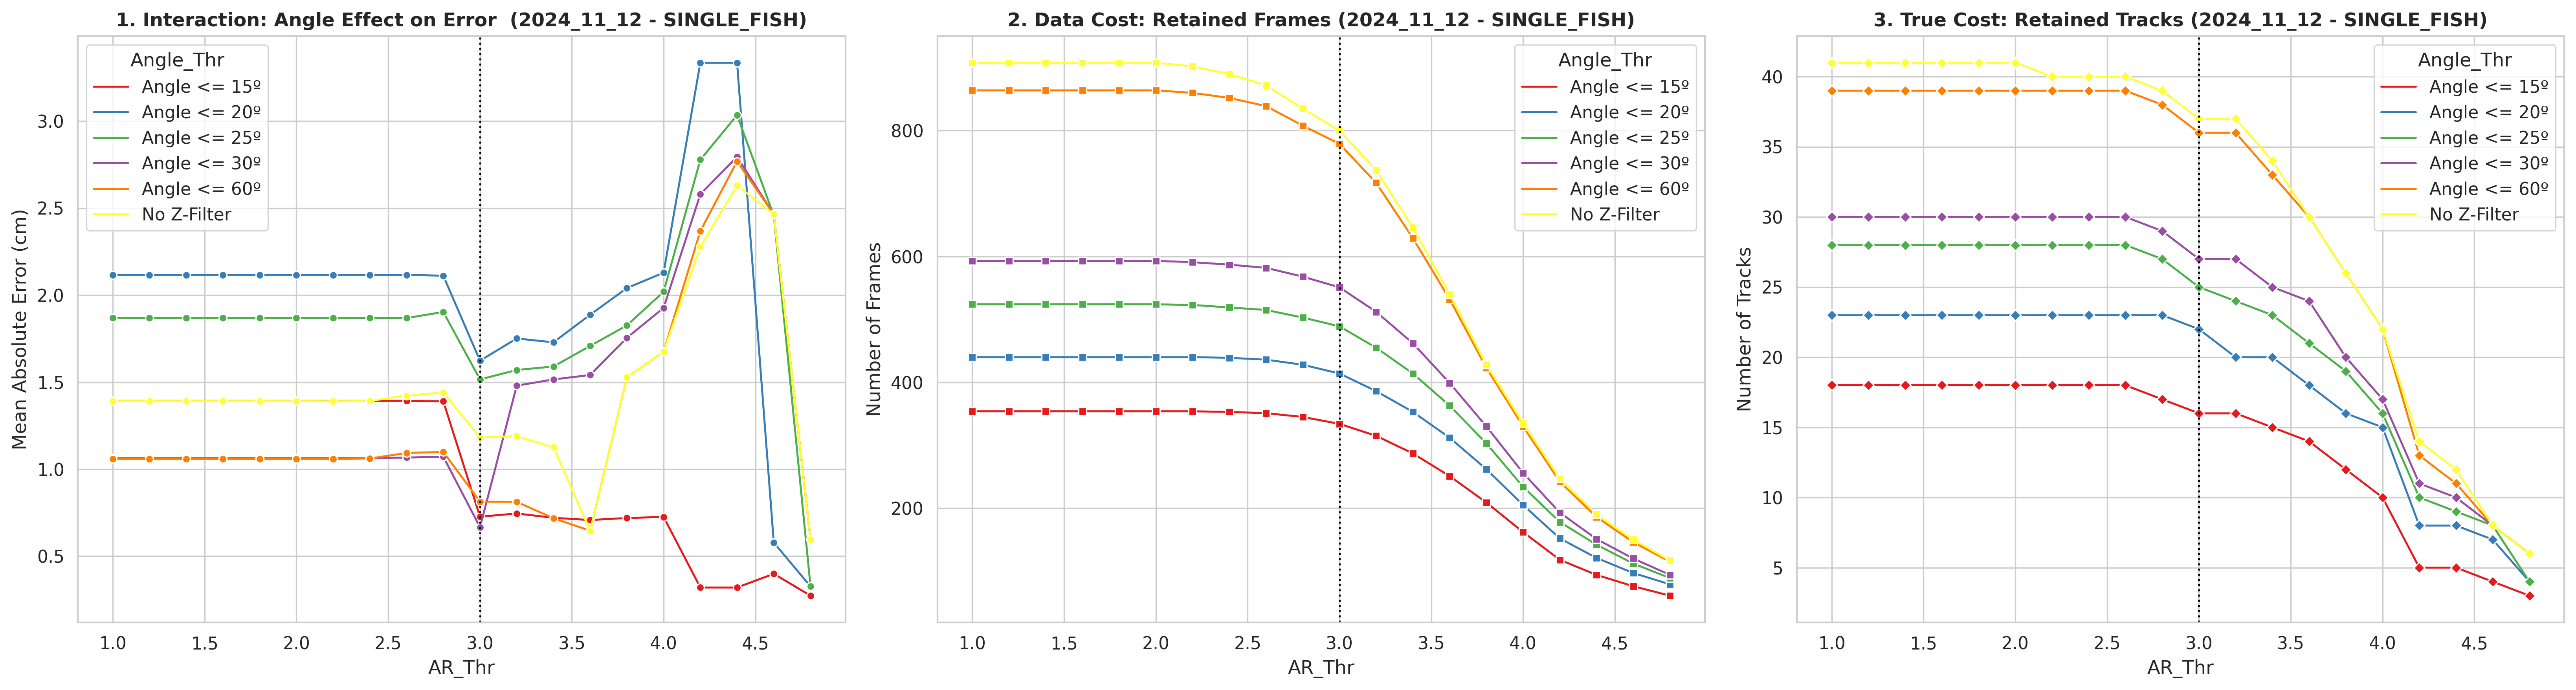


--- Processing Day: 2024_11_12 ---
Total initial tracks (valid GT): 127
📉 Tracks descartados por 'track_failure_from_frames': 75
📉 Tracks descartados por 'smart_aggregator': 31

SCENARIO        | Total Tracks | Measured   | MAE (cm)   | STD (cm)   | MAPE (%)  
-------------------------------------------------------------------------------------
single_fish     | 127          | 21         | 0.62       | 0.43       | 1.97      
-------------------------------------------------------------------------------------
GLOBAL DAY      | 127          | 21         | 0.62       | 0.43       | 1.97      



In [4]:
import pandas as pd
# Asumo que matplotlib, seaborn y rutils ya están importados arriba en tu notebook

# ===================================================================
# 1. LOAD & PREP DATA
# ===================================================================
day_code = "2024_11_12"
csv_path = "/home/slimbook/fish_sizing/ARTICLE/DATASET_1/2024_11_12/2024_11_12_ALL_raw_aggregated.csv"

# Asegúrate de tener definidos ASPECT_RATIO_THR y ANGLE_THR en celdas anteriores
df_raw_agg = pd.read_csv(csv_path)

# Filtrar GT no válidos (0 o negativos)
df_raw_agg = df_raw_agg[df_raw_agg['gt'] > 0].copy()

# Recalculate failure reason
df_raw_agg = rutils.assign_failure_reasons(df_raw_agg, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)

display(df_raw_agg.head())
print("SUMMARY RAW DATA")
display(df_raw_agg.describe())

# ===================================================================
# 2. FILTERING & AGGREGATION (Creando el df_filtered)
# ===================================================================
# Crear ID único por track (añadiendo el day_code y video_name para evitar colisiones)
if 'video_name' in df_raw_agg.columns:
    df_raw_agg['track_uid'] = day_code + "_" + df_raw_agg['video_name'].astype(str) + "_" + df_raw_agg['track_id'].astype(str)
else:
    df_raw_agg['track_uid'] = day_code + "_" + df_raw_agg['track_id'].astype(str)



# 2.1 Track failure evaluation
track_failures = df_raw_agg.groupby('track_uid').apply(rutils.track_failure_from_frames).rename('track_failure_reason')



# Keep only 'measured' tracks
measured_uids = track_failures[track_failures == 'measured'].index


df_measured = df_raw_agg[
    (df_raw_agg['track_uid'].isin(measured_uids)) & 
    (df_raw_agg['failure_reason'] == 'measured')
].copy()


total_initial_tracks = df_raw_agg['track_uid'].nunique()



# 2.2 Smart Aggregator
df_filtered = df_measured.groupby('track_uid').apply(rutils.smart_aggregator).dropna(how='all')


# 2.3 Recover metadata
cols_to_keep = ['scenario', 'video_name'] if 'video_name' in df_raw_agg.columns else ['scenario']
if 'especie_gt' in df_raw_agg.columns: cols_to_keep.append('especie_gt')
elif 'fish_id' in df_raw_agg.columns: cols_to_keep.append('fish_id')

track_metadata = df_raw_agg.groupby('track_uid').first()[cols_to_keep]
df_filtered = df_filtered.join(track_metadata).reset_index()

# Calculate errors
df_filtered['rel_error_perc'] = (df_filtered['abs_error_cm'] / df_filtered['gt_cm']) * 100

success_rate = (len(df_filtered) / total_initial_tracks) * 100 if total_initial_tracks > 0 else 0
print(f"✅ FINAL RESULT: {len(df_filtered)} independent FISH (tracks) successfully aggregated.")
print(f"📊 Success Rate: {success_rate:.2f}%")

# Guardar el resultado filtrado
filtered_csv_path = csv_path.replace(".csv", "_FILTERED.csv")
df_filtered.to_csv(filtered_csv_path, index=False)
print(f"💾 Guardado df_filtered en: {filtered_csv_path}")


# ===================================================================
# 4. RUTILS PLOTS (Tus gráficas usando los datos crudos/pipeline)
# ===================================================================
group = "single_fish" # o puedes hacerlo dinámico: group = df_raw_agg['scenario'].iloc[0]
context_label = f"{day_code} - {group.upper()}"

stacked_frames = rutils.plot_frame_failures(
    df_raw_agg, 
    aspect_ratio_thr=ASPECT_RATIO_THR, 
    angle_thr=ANGLE_THR,
    figsize_video=(12,6), 
    figsize_global=(5,5), 
    show_global=True,
    context_label=context_label
)

track_failures = rutils.plot_tracks_failure_distribution(
    df_raw_agg, 
    aspect_ratio_thr=ASPECT_RATIO_THR, 
    angle_thr=ANGLE_THR,
    show_global=True, 
    figsize_video=(12,6), 
    figsize_global=(5,5),
    context_label=context_label
)

rutils.plot_aspect_ratio_vs_length(
    df_raw_agg, 
    ASPECT_RATIO_THR=ASPECT_RATIO_THR, 
    figsize=(10, 8),
    context_label=context_label
) 

df_results = {}

stages_dict, agg_stages_dict = rutils.plot_ablation_pipeline(
    df_raw_agg, 
    ASPECT_RATIO_THR=ASPECT_RATIO_THR, 
    ANGLE_THR=ANGLE_THR,
    context_label=context_label  
)
print("Pipeline Stages Dictionary:")
# print(stages_dict)

rutils.plot_thresholds_interaction(
    df_raw_agg, 
    optimal_ar=3, 
    context=context_label
)

print(f"\n--- Processing Day: {day_code} ---")
print(f"Total initial tracks (valid GT): {total_initial_tracks}")

print(f"📉 Tracks descartados por 'track_failure_from_frames': {total_initial_tracks - len(measured_uids)}")
print(f"📉 Tracks descartados por 'smart_aggregator': {len(measured_uids) - len(df_filtered)}")
# ===================================================================
# 3. SUMMARY TABLE FOR THE DAY
# ===================================================================
print("\n" + "="*85)
print(f"{'SCENARIO':<15} | {'Total Tracks':<12} | {'Measured':<10} | {'MAE (cm)':<10} | {'STD (cm)':<10} | {'MAPE (%)':<10}")
print("-" * 85)

# Iterar por los escenarios que haya en este día (ej. single_fish, multiple_fish)
scenarios = df_raw_agg['scenario'].unique() if 'scenario' in df_raw_agg.columns else ['All']

for sc in scenarios:
    if sc == 'All':
        n_total = df_raw_agg['track_uid'].nunique()
        sub_final = df_filtered
    else:
        n_total = df_raw_agg[df_raw_agg['scenario'] == sc]['track_uid'].nunique()
        sub_final = df_filtered[df_filtered['scenario'] == sc]
        
    n_measured = len(sub_final)
    
    if n_measured > 0:
        mae = sub_final['abs_error_cm'].mean()
        std = sub_final['abs_error_cm'].std()
        mape = sub_final['rel_error_perc'].mean()
    else:
        mae = std = mape = 0.0
        
    print(f"{sc:<15} | {n_total:<12} | {n_measured:<10} | {mae:<10.2f} | {std:<10.2f} | {mape:<10.2f}")

# Fila Global del día
print("-" * 85)
mae_glob = df_filtered['abs_error_cm'].mean() if len(df_filtered)>0 else 0
std_glob = df_filtered['abs_error_cm'].std() if len(df_filtered)>0 else 0
mape_glob = df_filtered['rel_error_perc'].mean() if len(df_filtered)>0 else 0
print(f"{'GLOBAL DAY':<15} | {total_initial_tracks:<12} | {len(df_filtered):<10} | {mae_glob:<10.2f} | {std_glob:<10.2f} | {mape_glob:<10.2f}")
print("="*85 + "\n")

In [5]:
df_filtered

,track_uid,n_frames_validos,calculated_length_cm,gt_cm,abs_error_cm,mean_elevation_deg,scenario,video_name,especie_gt,rel_error_perc
0,2024_11_12_10_48_44_0_-1,13.0,30.195400,31.5,1.304600,1.777572,single_fish,10_48_44_0,lubina0,4.141587
1,2024_11_12_10_48_44_0_24,38.0,31.039335,31.5,0.460665,-10.741806,single_fish,10_48_44_0,lubina0,1.462427
2,2024_11_12_10_48_44_1_-1,6.0,30.176761,31.5,1.323239,-1.601370,single_fish,10_48_44_1,lubina0,4.200757
3,2024_11_12_10_48_44_1_12,28.0,31.141903,31.5,0.358097,0.146316,single_fish,10_48_44_1,lubina0,1.136815
4,2024_11_12_10_48_44_1_29,11.0,30.795336,31.5,0.704664,-2.562169,single_fish,10_48_44_1,lubina0,2.237028
5,2024_11_12_10_54_07_0_-1,9.0,30.750411,31.5,0.749589,5.684229,single_fish,10_54_07_0,lubina0,2.379648
6,2024_11_12_10_54_07_0_15,9.0,31.033027,31.5,0.466973,-13.857779,single_fish,10_54_07_0,lubina0,1.482454
7,2024_11_12_10_54_07_0_34,9.0,30.789324,31.5,0.710676,0.256343,single_fish,10_54_07_0,lubina0,2.256113
8,2024_11_12_10_58_20_0_15,22.0,31.502105,31.5,0.002105,-1.436156,single_fish,10_58_20_0,lubina0,0.006683
9,2024_11_12_10_58_20_0_8,8.0,31.376332,31.5,0.123668,-1.115534,single_fish,10_58_20_0,lubina0,0.392598


In [6]:
df_raw_agg

,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,...,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,especie_gt,failure_reason,unique_track,scenario,track_uid
0,2024_11_12,10_44_11_0,10_44_11_0,frame_1,0,255,-1,1,False,False,...,NaN,31.5,NaN,NaN,NaN,lubina0,aspect_ratio_fail,2024_11_12/10_44_11_0/-1,single_fish,2024_11_12_10_44_11_0_-1
1,2024_11_12,10_44_11_0,10_44_11_0,frame_9,0,255,-1,1,False,False,...,NaN,31.5,NaN,NaN,NaN,lubina0,other,2024_11_12/10_44_11_0/-1,single_fish,2024_11_12_10_44_11_0_-1
2,2024_11_12,10_44_11_0,10_44_11_0,frame_12,0,255,-1,0,True,False,...,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_44_11_0/-1,single_fish,2024_11_12_10_44_11_0_-1
3,2024_11_12,10_44_11_0,10_44_11_0,frame_13,0,255,3,0,True,False,...,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_44_11_0/3,single_fish,2024_11_12_10_44_11_0_3
4,2024_11_12,10_44_11_0,10_44_11_0,frame_15,0,255,3,0,True,False,...,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_44_11_0/3,single_fish,2024_11_12_10_44_11_0_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2165,2024_11_12,10_48_44_0,10_48_44_0,frame_655,0,255,43,1,False,False,...,0.279093,31.5,2.592832,8.231213,0.841480,lubina0,angle_fail,2024_11_12/10_48_44_0/43,single_fish,2024_11_12_10_48_44_0_43
2166,2024_11_12,10_48_44_0,10_48_44_0,frame_656,0,255,43,1,False,False,...,0.278997,31.5,2.519492,7.998387,0.844902,lubina0,measured,2024_11_12/10_48_44_0/43,single_fish,2024_11_12_10_48_44_0_43
2167,2024_11_12,10_48_44_0,10_48_44_0,frame_657,0,255,43,1,False,False,...,NaN,31.5,NaN,NaN,NaN,lubina0,other,2024_11_12/10_48_44_0/43,single_fish,2024_11_12_10_48_44_0_43
2168,2024_11_12,10_48_44_0,10_48_44_0,frame_658,0,255,43,1,True,False,...,NaN,31.5,NaN,NaN,NaN,lubina0,borders,2024_11_12/10_48_44_0/43,single_fish,2024_11_12_10_48_44_0_43


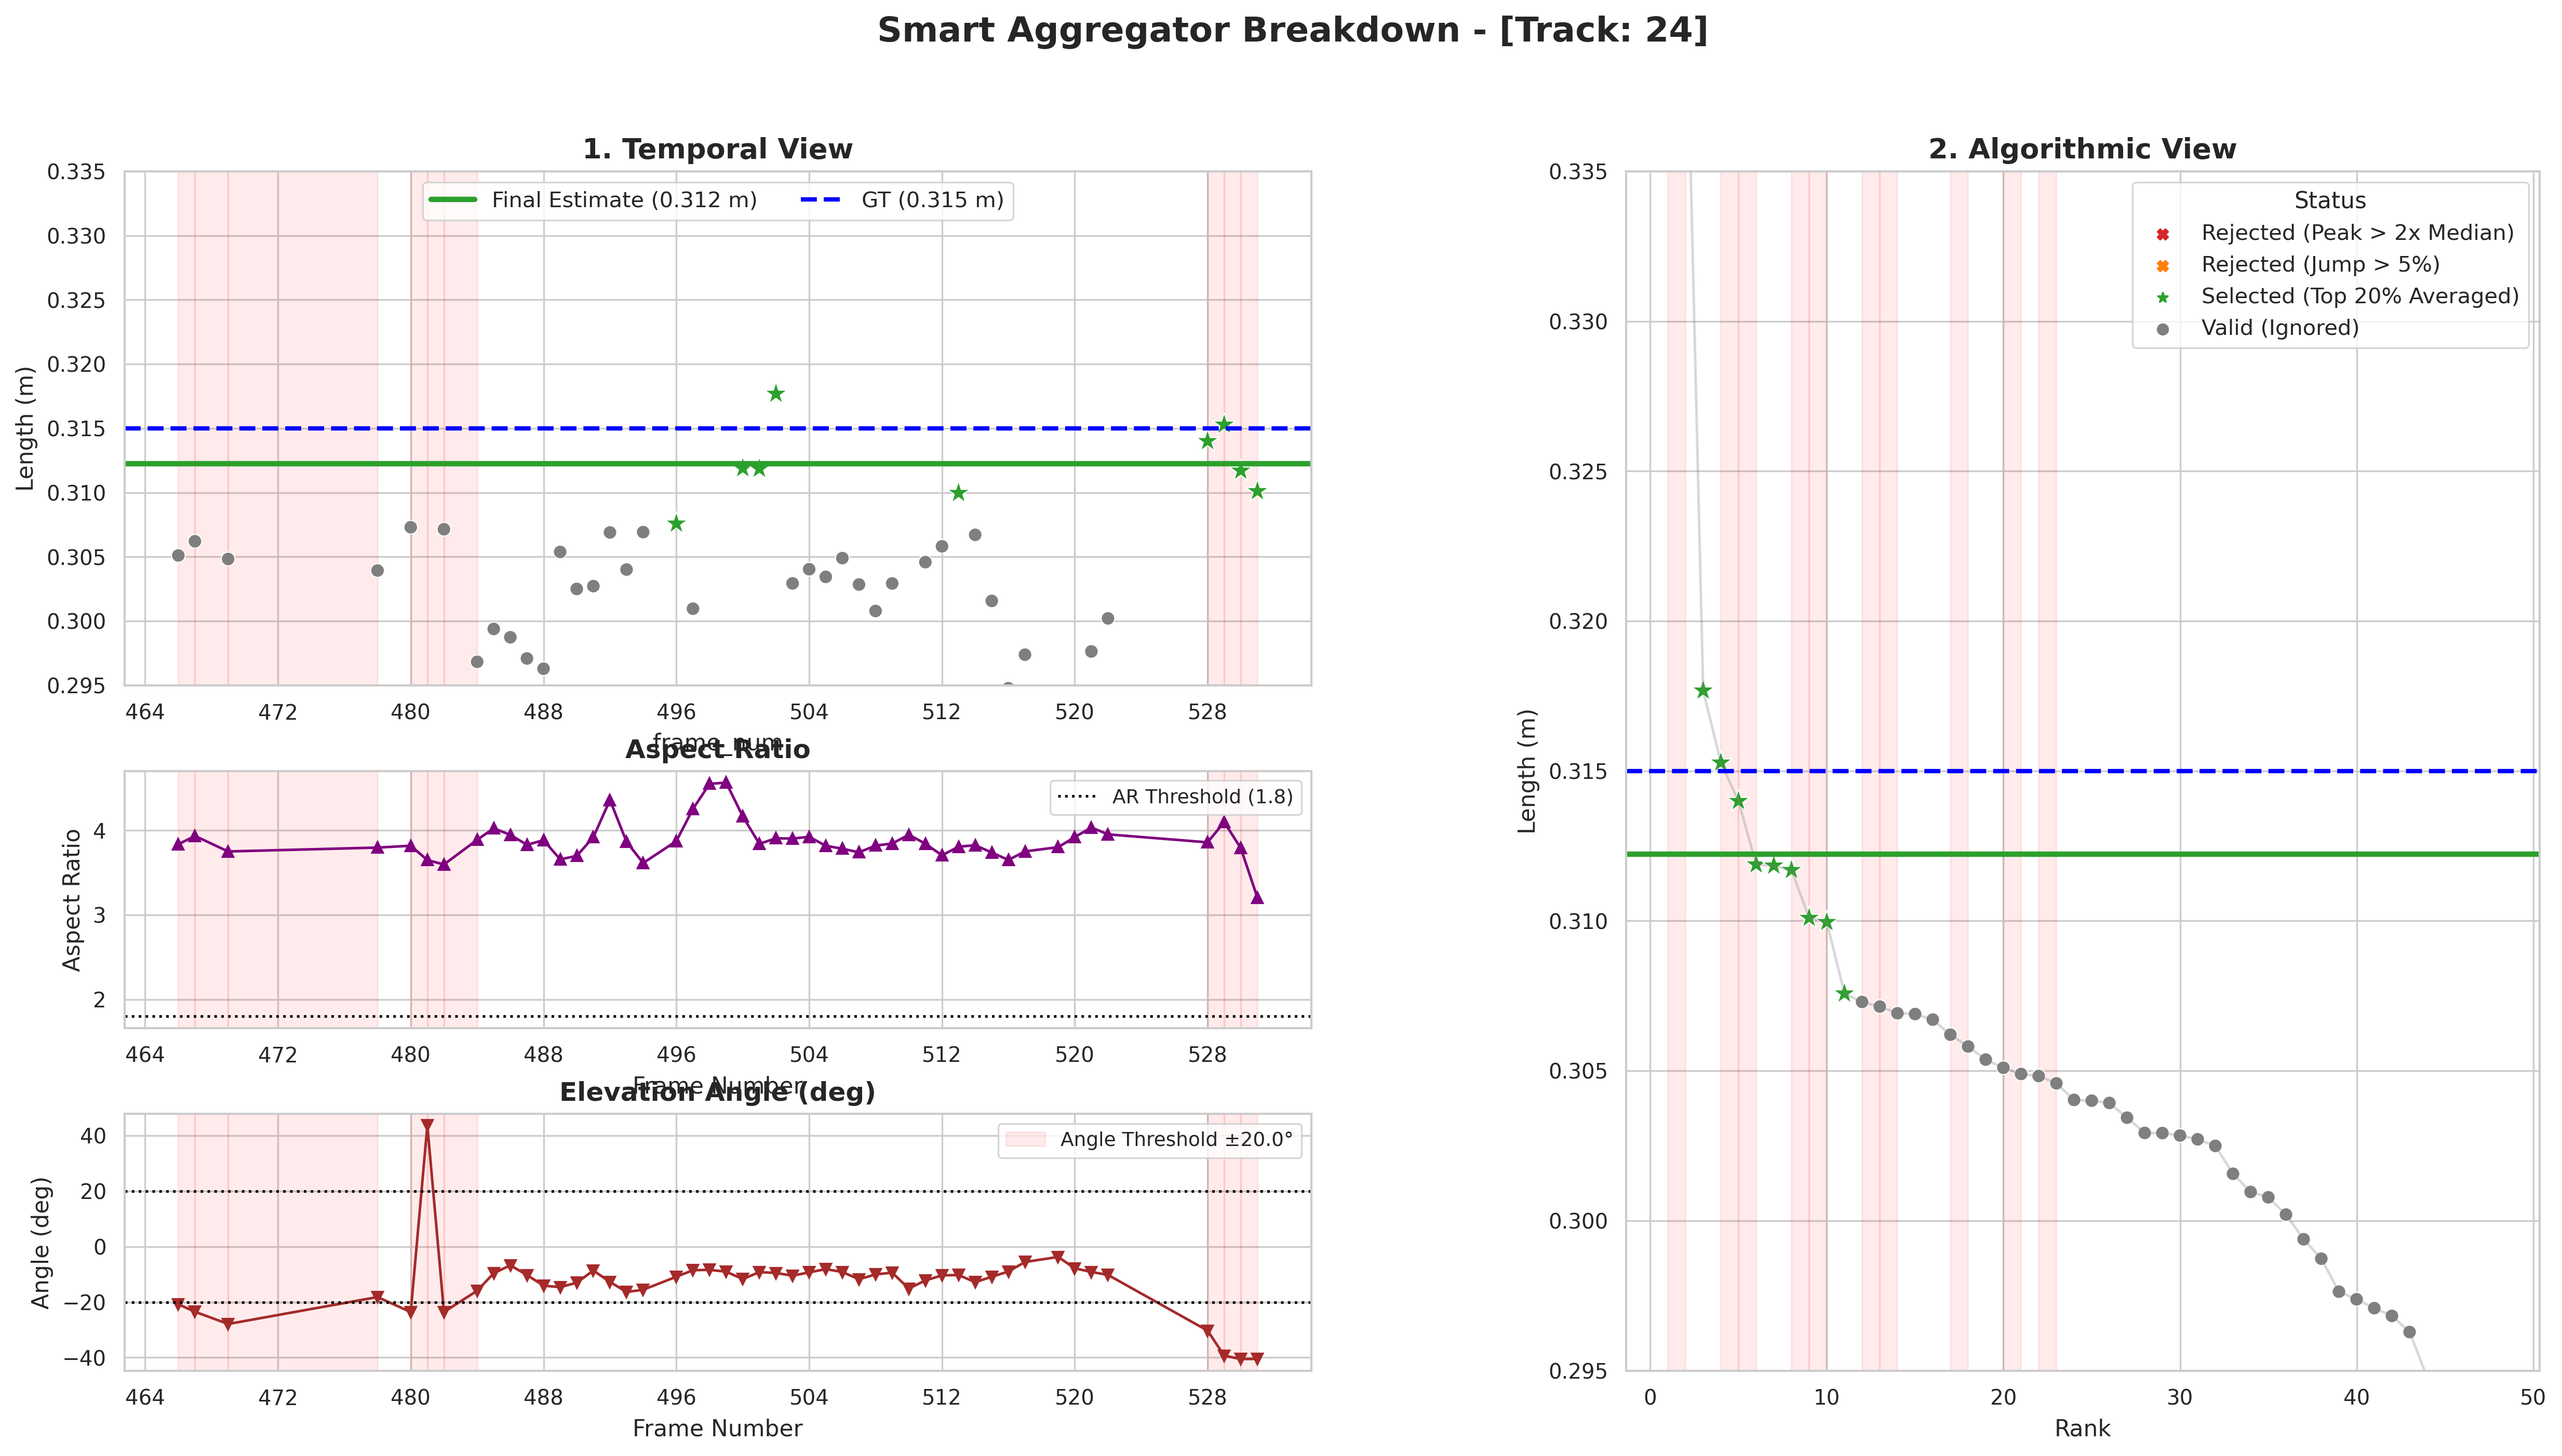

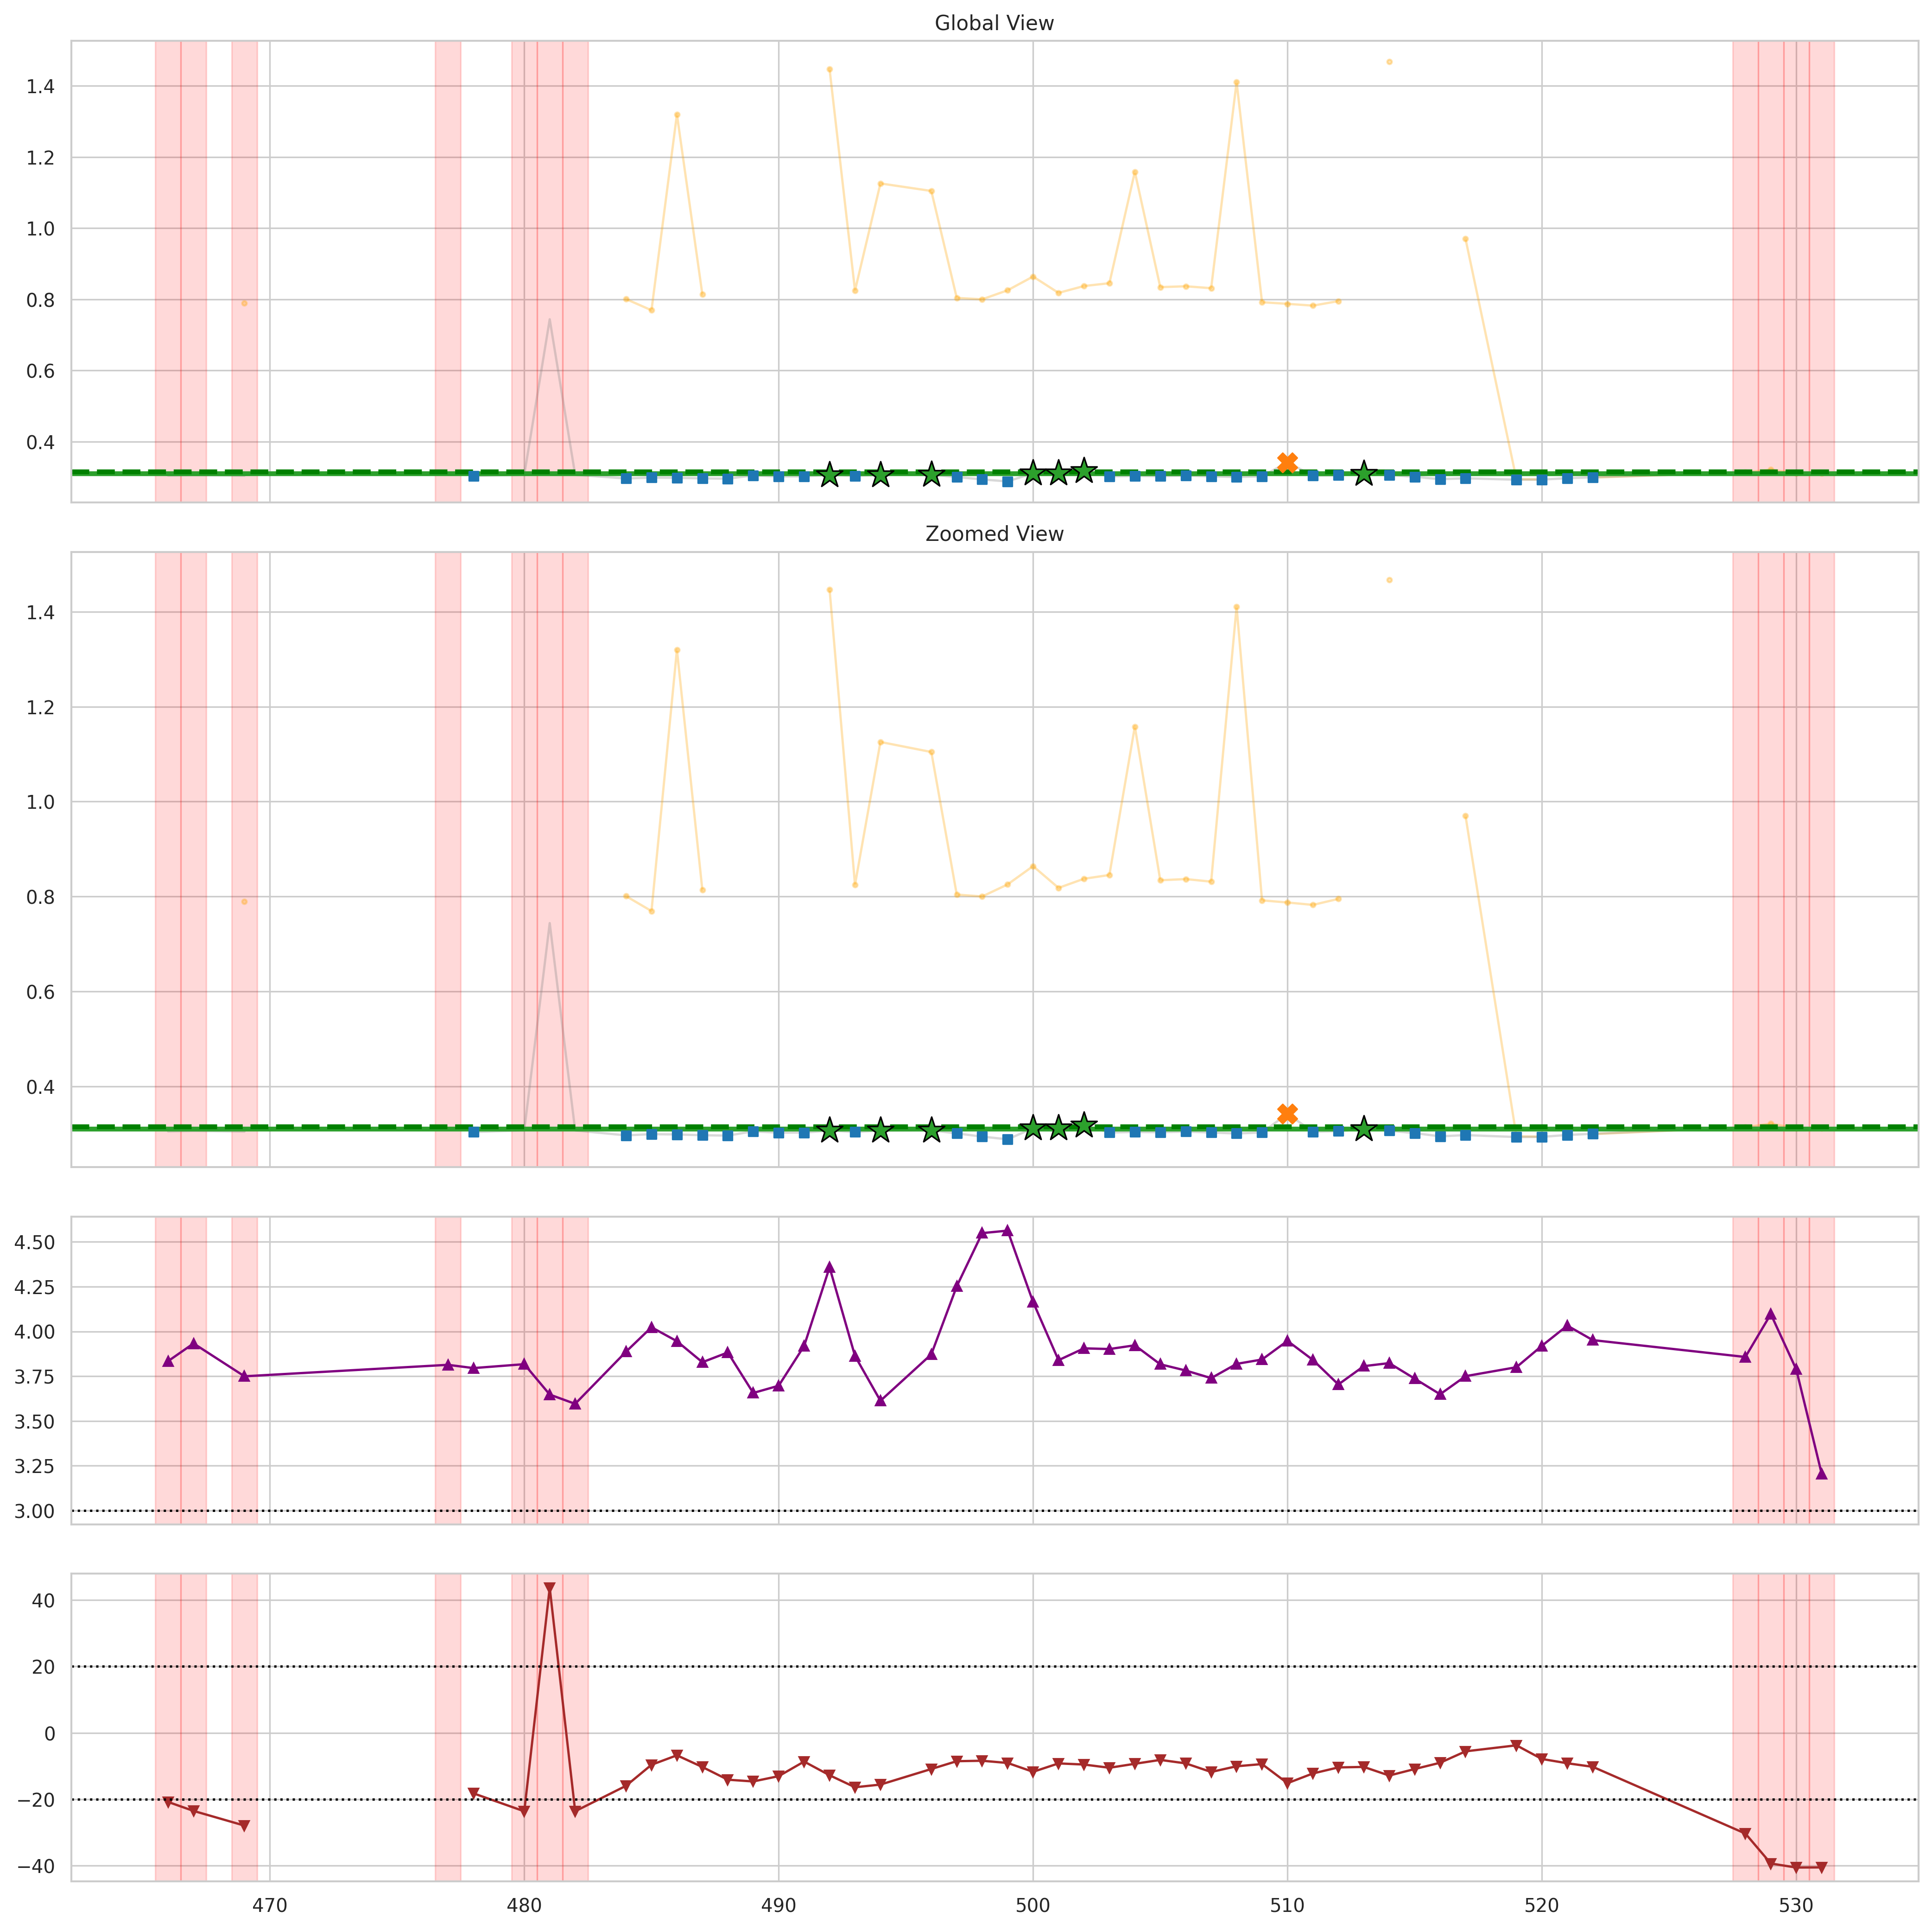

In [7]:

rutils.plot_smart_filter_explanation_pro(df_raw_agg, "10_48_44_0", 24)


rutils.plot_track_evolution_detailed(df_raw_agg, "10_48_44_0", 24)

In [8]:
df_raw

plot_smart_filter_explanation_pro(df_raw, "12_07_31_0", 1)
# df_res_5_angle.style.format(lambda x: f"{x:.3f}".rstrip('0').rstrip('.') if isinstance(x, float) else x)

# df_res_5_angle.sort_values(by="abs_error_cm", ascending=False)\
#     .style.format(lambda x: f"{x:.3f}".rstrip('0').rstrip('.') if isinstance(x, float) else x)

NameError: name 'df_raw' is not defined

In [ ]:
plot_smart_filter_explanation_pro(df_base[mask_5], "12_12_06_compressed", 1)

❌ ERROR: No se encontraron datos para la carpeta '12_12_06_compressed' y track '1'


Calculando interacción entre Aspect Ratio y Ángulo...


Evaluando Ángulos: 100%|██████████| 4/4 [00:00<00:00,  4.98it/s]


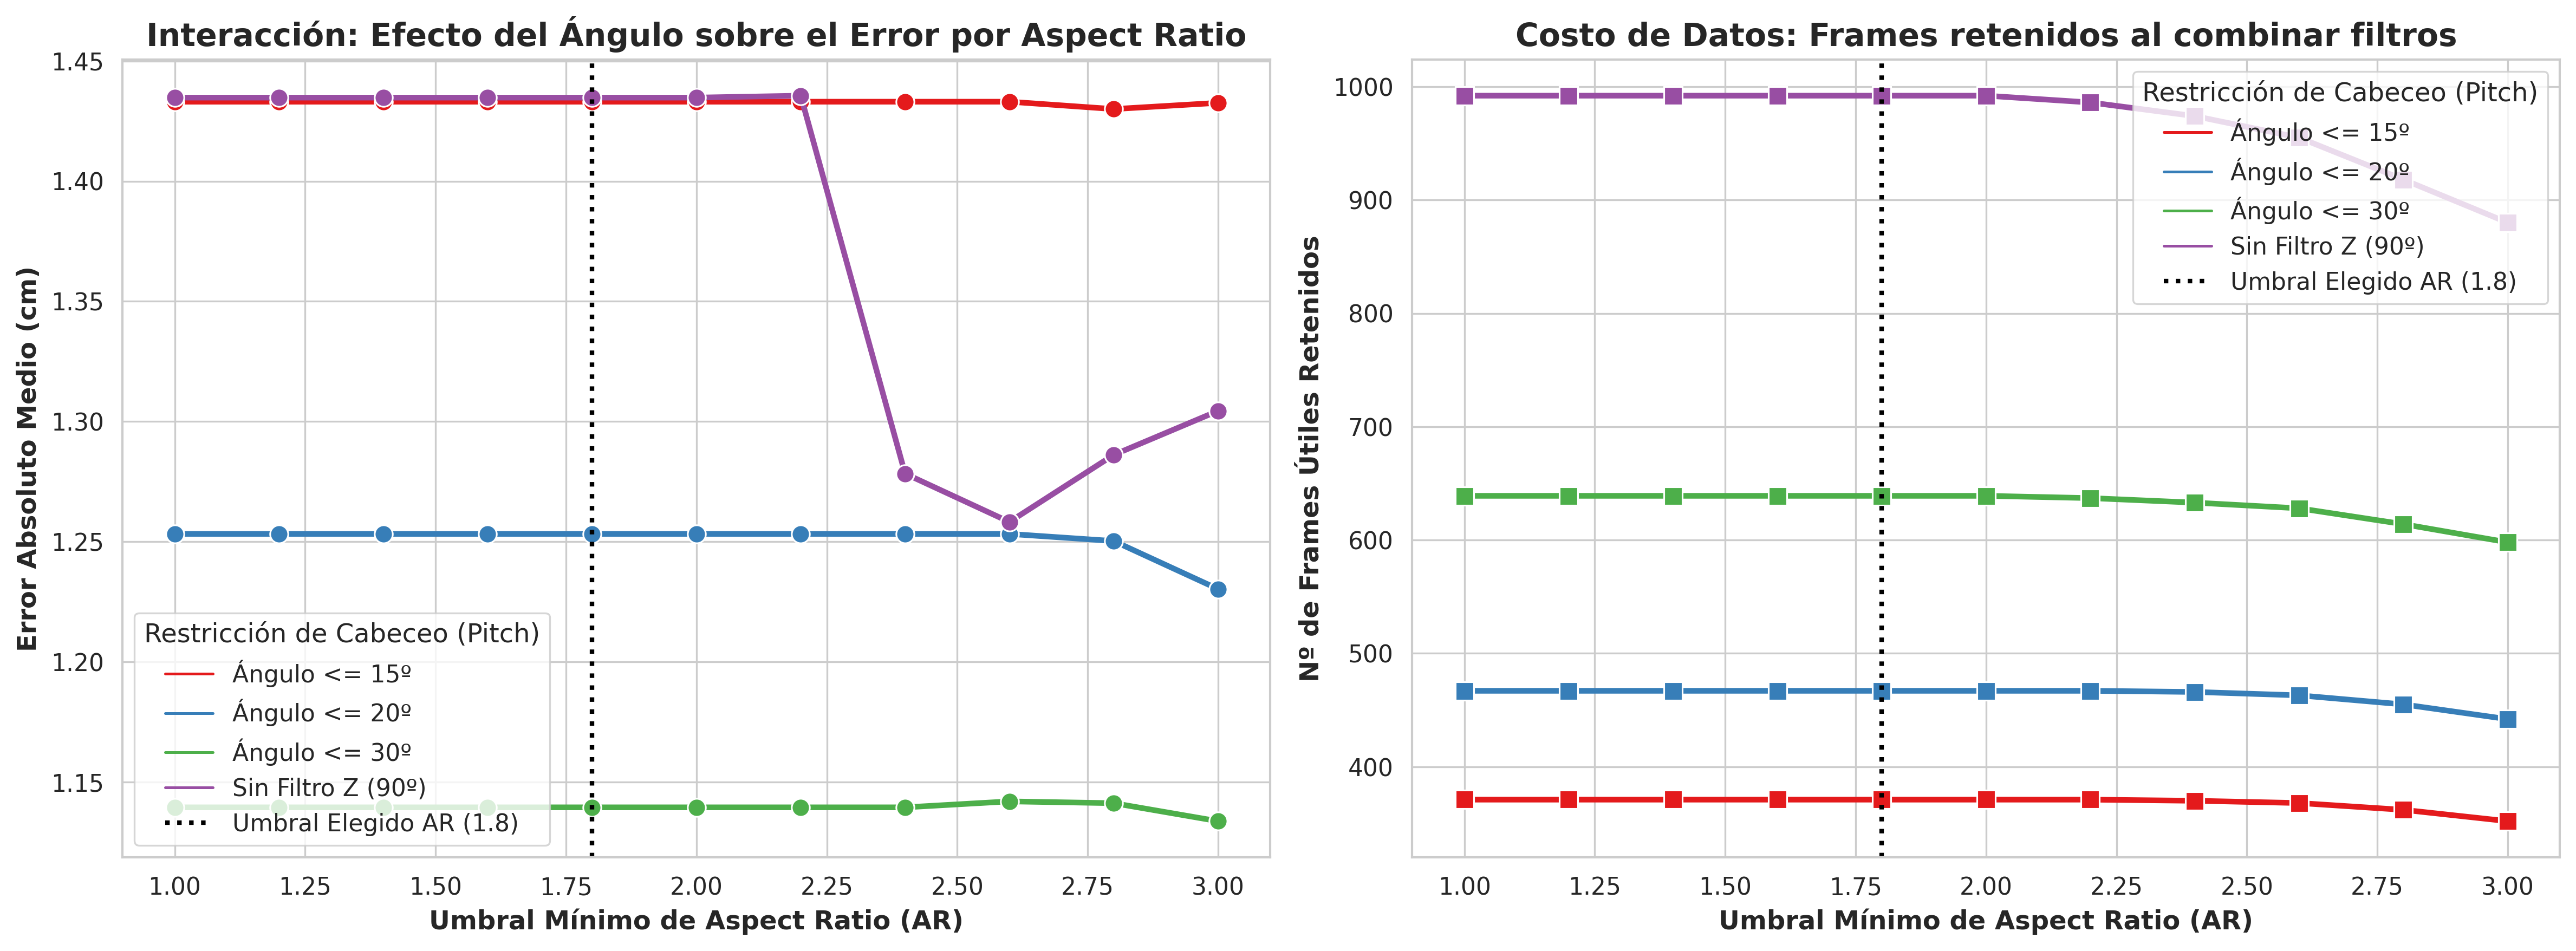

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm # Para ver la barra de progreso en Jupyter
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. PREPARAR DATOS BASE
# =====================================================================
df_base = df_raw[
    (df_raw['is_3D_complete'] == True) &
    (df_raw['in_image_borders'] == False) &
    (df_raw['does_overlap'] == False) &
    (df_raw['filtered_length'] > 0)
].copy()

# =====================================================================
# 2. FUNCIÓN DE EVALUACIÓN
# =====================================================================
def evaluate_thresholds(df, ar_thr, angle_thr):
    df_filt = df[(df['aspect_ratio'] >= ar_thr) & (df['elevation_deg'].abs() <= angle_thr)]
    if df_filt.empty: return np.nan, 0, 0
    
    df_agg = df_filt.groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()
    if df_agg.empty: return np.nan, 0, 0
    
    mean_err = df_agg['abs_error_cm'].mean()
    retained_frames = len(df_filt)
    retained_tracks = len(df_agg)
    
    return mean_err, retained_frames, retained_tracks


def plot_triple_axis(ax, x_data, y_error, y_frames, y_tracks, title, xlabel, optimal_x):
    # Eje Izquierdo: Error (Azul)
    color_err = '#1f77b4' 
    ax.plot(x_data, y_error, marker='o', color=color_err, linewidth=2.5, label='Error Absoluto (cm)')
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel('Error Absoluto Medio (cm)', color=color_err, fontweight='bold')
    ax.tick_params(axis='y', labelcolor=color_err)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Eje Derecho 1: Frames (Rojo)
    ax2 = ax.twinx()
    color_frames = '#d62728' 
    ax2.plot(x_data, y_frames, marker='s', color=color_frames, linestyle='--', linewidth=2, label='Frames Retenidos')
    ax2.set_ylabel('Nº de Frames Retenidos', color=color_frames, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_frames)
    
    # Eje Derecho 2: TRACKS (Verde) desplazado hacia afuera
    ax3 = ax.twinx()
    ax3.spines['right'].set_position(('outward', 65)) # Aleja este eje 65 píxeles a la derecha
    color_tracks = '#2ca02c'
    ax3.plot(x_data, y_tracks, marker='^', color=color_tracks, linestyle='-.', linewidth=2, label='Peces (Tracks) Retenidos')
    ax3.set_ylabel('Nº de Peces Retenidos', color=color_tracks, fontweight='bold')
    ax3.tick_params(axis='y', labelcolor=color_tracks)
    
    # Marcar el punto óptimo
    ax.axvline(x=optimal_x, color='black', linestyle=':', linewidth=2, label=f'Umbral Elegido ({optimal_x})')
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    
    # Juntar leyendas de los tres ejes
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_3, labels_3 = ax3.get_legend_handles_labels()
    
    # Ponemos la leyenda combinada en el mejor sitio del eje principal
    ax.legend(lines_1 + lines_2 + lines_3, labels_1 + labels_2 + labels_3, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# =====================================================================
# 1. RECOPILAR DATOS COMBINADOS
# =====================================================================
print("Calculando interacción entre Aspect Ratio y Ángulo...")

ar_range = np.arange(1.0, 3.2, 0.2)
# Probamos tu ángulo óptimo (20), uno más estricto (15), uno más relajado (30) y sin filtro (90)
angles_to_test = [15, 20, 30, 90] 

results = []

for ang in tqdm(angles_to_test, desc="Evaluando Ángulos"):
    for ar in ar_range:
        err, frames, tracks = evaluate_thresholds(df_base, ar_thr=ar, angle_thr=ang)
        
        # Etiqueta para la leyenda
        if ang == 90:
            ang_label = "Sin Filtro Z (90º)"
        else:
            ang_label = f"Ángulo <= {ang}º"
            
        results.append({
            'Angle_Thr': ang_label,
            'AR_Thr': ar,
            'Error_cm': err,
            'Frames': frames,
            'Tracks': tracks
        })

df_interaction = pd.DataFrame(results)

# =====================================================================
# 2. PLOTEAR INTERACCIÓN (PAPER-READY)
# =====================================================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Paleta de colores: que resalte bien la diferencia entre líneas
palette = sns.color_palette("Set1", n_colors=len(angles_to_test))

# --- PANEL IZQUIERDO: ERROR ABSOLUTO ---
sns.lineplot(data=df_interaction, x='AR_Thr', y='Error_cm', hue='Angle_Thr', 
             marker='o', markersize=8, linewidth=2.5, palette=palette, ax=axes[0])

axes[0].axvline(x=1.8, color='black', linestyle=':', linewidth=2, label='Umbral Elegido AR (1.8)')
axes[0].set_title("Interacción: Efecto del Ángulo sobre el Error por Aspect Ratio", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Umbral Mínimo de Aspect Ratio (AR)", fontweight='bold')
axes[0].set_ylabel("Error Absoluto Medio (cm)", fontweight='bold')
axes[0].legend(title="Restricción de Cabeceo (Pitch)")

# --- PANEL DERECHO: FRAMES RETENIDOS ---
sns.lineplot(data=df_interaction, x='AR_Thr', y='Frames', hue='Angle_Thr', 
             marker='s', markersize=8, linewidth=2.5, palette=palette, ax=axes[1])

axes[1].axvline(x=1.8, color='black', linestyle=':', linewidth=2, label='Umbral Elegido AR (1.8)')
axes[1].set_title("Costo de Datos: Frames retenidos al combinar filtros", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Umbral Mínimo de Aspect Ratio (AR)", fontweight='bold')
axes[1].set_ylabel("Nº de Frames Útiles Retenidos", fontweight='bold')
axes[1].legend(title="Restricción de Cabeceo (Pitch)")

plt.tight_layout()
plt.show()



In [ ]:


def plot_track_evolution(df, folder_code, track_id, ar_thr=1.8):
    """
    Plotea la evolución temporal de las medidas RAW vs FILTRADAS de un pez específico.
    """
    # 1. Búsqueda segura
    folder_str = str(folder_code)
    track_str = str(track_id)
    
    mask = (df['source_folder'].astype(str) == folder_str) & (df['track_id'].astype(str) == track_str)
    fish_data = df[mask].copy()
    
    if fish_data.empty:
        print(f"❌ ERROR: No se encontraron datos para la carpeta '{folder_str}' y track '{track_str}'")
        return
        
    # --- LA SOLUCIÓN AL ERROR ---
    # Extraemos solo los dígitos del frame_id y lo convertimos a número entero.
    # Así "frame_0015" o "15" se convierte en el número matemático 15.
    fish_data['frame_num'] = fish_data['frame_id'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
    
    # 3. Ordenamos temporalmente de verdad (el 2 irá antes que el 10)
    fish_data = fish_data.sort_values(by='frame_num')
    
    gt_cm = fish_data['gt'].iloc[0]
    gt_m = gt_cm / 100.0 if gt_cm > 0 else None
    
    # 4. PLOT
    plt.figure(figsize=(12, 6))
    
    # Ploteamos Raw Length usando el frame_num matemático en el EJE X
    plt.plot(fish_data['frame_num'], fish_data['raw_length'], 
             marker='o', linestyle='-', color='orange', alpha=0.6, label='Raw Length 3D')
    
    # Ploteamos Filtered Length
    plt.plot(fish_data['frame_num'], fish_data['filtered_length'], 
             marker='s', linestyle='-', color='blue', alpha=0.8, label='Filtered Length (HDBSCAN)')
    
    if gt_m is not None:
        plt.axhline(y=gt_m, color='green', linestyle='--', linewidth=2.5, 
                    label=f'Ground Truth ({gt_m:.3f} m)')
        
    # Sombrear las zonas malas
    is_3d_ok = fish_data['is_3D_complete'].fillna(False).astype(bool)
    is_ar_ok = fish_data['aspect_ratio'].fillna(0) >= ar_thr
    
    perfect_mask = is_3d_ok & is_ar_ok
    bad_frames = fish_data[~perfect_mask]['frame_num'] # Extraemos el número matemático
    
    # Ahora sí podemos restar 0.5 sin que explote
    for bf in bad_frames:
        plt.axvspan(bf - 0.5, bf + 0.5, color='red', alpha=0.1)
        
    # Parche invisible para la leyenda
    red_patch = mpatches.Patch(color='red', alpha=0.1, label='Frame Descartado (Filtros no superados)')
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.append(red_patch)

    plt.title(f"Evolución Temporal de las Medidas - [Carpeta: {folder_str} | Track ID: {track_str}]", fontsize=14, fontweight='bold')
    plt.xlabel("Número de Frame", fontsize=12, fontweight='bold')
    plt.ylabel("Longitud Medida (Metros)", fontsize=12, fontweight='bold')
    
    # Forzamos que el eje X muestre números de frame exactos (no decimales como frame 12.5)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(handles=handles, loc='best')
    plt.tight_layout()
    plt.show()

# EJEMPLO DE USO 
# plot_track_evolution(df_raw, "12_07_31_0", 1)



def plot_track_evolution_detailed(df, folder_code, track_id, ar_thr=1.8, angle_thr=20.0):
    """
    Plotea la evolución temporal de la medida, el aspect ratio y el ángulo de elevación.
    """
    folder_str = str(folder_code)
    track_str = str(track_id)
    
    mask = (df['source_folder'].astype(str) == folder_str) & (df['track_id'].astype(str) == track_str)
    fish_data = df[mask].copy()
    
    if fish_data.empty:
        print(f"❌ ERROR: No se encontraron datos para la carpeta '{folder_str}' y track '{track_str}'")
        return
        
    # Extraer frame matemático
    fish_data['frame_num'] = fish_data['frame_id'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
    fish_data = fish_data.sort_values(by='frame_num')
    
    gt_cm = fish_data['gt'].iloc[0]
    gt_m = gt_cm / 100.0 if gt_cm > 0 else None
    
    # Encontrar frames malos
    is_3d_ok = fish_data['is_3D_complete'].fillna(False).astype(bool)
    is_ar_ok = fish_data['aspect_ratio'].fillna(0) >= ar_thr
    is_angle_ok = fish_data['elevation_deg'].fillna(90).abs() <= angle_thr
    
    perfect_mask = is_3d_ok & is_ar_ok & is_angle_ok
    bad_frames = fish_data[~perfect_mask]['frame_num']
    
    # --- CREAR LA FIGURA CON 3 PANELES ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})
    fig.suptitle(f"Análisis Cinemático y Medición - [Carpeta: {folder_str} | Track ID: {track_str}]", fontsize=15, fontweight='bold', y=0.96)
    
    # ==========================================
    # PANEL 1: LONGITUD (Y-lim: 0.05 a 0.45)
    # ==========================================
    ax1 = axes[0]
    ax1.plot(fish_data['frame_num'], fish_data['raw_length'], marker='o', color='orange', alpha=0.6, label='Raw Length 3D')
    ax1.plot(fish_data['frame_num'], fish_data['filtered_length'], marker='s', color='blue', alpha=0.8, label='Filtered Length (HDBSCAN)')
    
    if gt_m is not None:
        ax1.axhline(y=gt_m, color='green', linestyle='--', linewidth=2.5, label=f'Ground Truth ({gt_m:.3f} m)')
    
    ax1.set_ylim(0.05, 0.45)
    # Rejilla detallada cada 5 cm (0.05 m)
    ax1.yaxis.set_major_locator(MultipleLocator(0.05))
    ax1.yaxis.set_minor_locator(MultipleLocator(0.01))
    ax1.grid(True, which='major', linestyle='-', alpha=0.7)
    ax1.grid(True, which='minor', linestyle=':', alpha=0.4)
    
    ax1.set_ylabel("Longitud Medida (m)", fontweight='bold')
    ax1.legend(loc='upper right')
    
    # ==========================================
    # PANEL 2: ASPECT RATIO
    # ==========================================
    ax2 = axes[1]
    ax2.plot(fish_data['frame_num'], fish_data['aspect_ratio'], marker='^', color='purple', linewidth=2)
    ax2.axhline(y=ar_thr, color='black', linestyle=':', linewidth=2, label=f'Umbral AR ({ar_thr})')
    
    ax2.set_ylabel("Aspect Ratio", fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right')
    
    # ==========================================
    # PANEL 3: ÁNGULO DE ELEVACIÓN (PITCH)
    # ==========================================
    ax3 = axes[2]
    ax3.plot(fish_data['frame_num'], fish_data['elevation_deg'], marker='v', color='brown', linewidth=2)
    ax3.axhline(y=angle_thr, color='black', linestyle=':', linewidth=2, label=f'Umbral Ángulo (±{angle_thr}º)')
    ax3.axhline(y=-angle_thr, color='black', linestyle=':', linewidth=2)
    
    ax3.set_ylabel("Ángulo Z (º)", fontweight='bold')
    ax3.set_xlabel("Número de Frame", fontsize=12, fontweight='bold')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='upper right')
    
    # ==========================================
    # SOMBREAR FRAMES MALOS EN LOS 3 PANELES
    # ==========================================
    for ax in axes:
        for bf in bad_frames:
            ax.axvspan(bf - 0.5, bf + 0.5, color='red', alpha=0.1)
            
    # Forzar enteros en el eje X compartido
    axes[2].xaxis.set_major_locator(MaxNLocator(integer=True))
    
    plt.tight_layout()
    plt.show()

# EJEMPLO DE USO
# plot_track_evolution_detailed(df_raw, "12_07_31_0", 1)

In [ ]:
df_raw

,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,...,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,unique_track
0,10_44_11_0,frame_1,0,255,-1,True,False,False,True,2.879445,...,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11_0_-1
1,10_44_11_0,frame_9,0,255,-1,True,False,False,True,3.122189,...,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11_0_-1
2,10_44_11_0,frame_12,0,255,-1,False,True,False,True,3.172235,...,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11_0_-1
3,10_44_11_0,frame_13,0,255,3,False,True,False,True,3.169992,...,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11_0_3
4,10_44_11_0,frame_15,0,255,3,False,True,False,True,2.762195,...,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11_0_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2335,10_48_44_0,frame_655,0,255,43,True,False,False,True,5.873219,...,-25.437106,-25.386546,0.774454,0.289072,0.279093,31.5,2.592832,8.231213,0.841480,10_48_44_0_43
2336,10_48_44_0,frame_656,0,255,43,True,False,False,True,7.017872,...,-19.537024,-29.343617,0.744740,0.289805,0.278997,31.5,2.519492,7.998387,0.844902,10_48_44_0_43
2337,10_48_44_0,frame_657,0,255,43,True,False,False,True,7.142857,...,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_48_44_0_43
2338,10_48_44_0,frame_658,0,255,43,True,True,False,True,6.666667,...,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_48_44_0_43


In [ ]:
df_res_5_angle.sort_values(by="abs_error_cm", ascending=False)\
    .style.format(lambda x: f"{x:.3f}".rstrip('0').rstrip('.') if isinstance(x, float) else x)

,source_folder,track_id,n_frames_validos,calculated_length_cm,gt_cm,abs_error_cm,mean_elevation_deg
0,10_44_11_0,3,4,43.593,31.5,12.093,1.369
3,10_48_44_0,40,3,35.943,31.5,4.443,5.684
22,11_00_27_0,21,5,29.23,31.5,2.27,12.9
25,11_00_27_new_calibration_calib,21,5,29.23,31.5,2.27,12.9
24,11_00_27_new_calibration_calib,12,13,33,31.5,1.5,-10.594
21,11_00_27_0,12,13,33,31.5,1.5,-10.594
10,10_54_07_0,3,3,30.065,31.5,1.435,8.176
19,10_58_20_0,21,4,30.087,31.5,1.413,-7.959
5,10_48_44_1,-1,6,30.177,31.5,1.323,-1.601
1,10_48_44_0,-1,13,30.195,31.5,1.305,1.778


In [ ]:
df_raw[df_raw["source_folder"]=="2024_11_12-11_37_10-0"]

,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,...,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,unique_track


In [ ]:

plot_track_evolution(df_raw,"2024_11_12-10_44_11-0",51)

❌ ERROR: No se encontraron datos para la carpeta '2024_11_12-10_44_11-0' y track '51'


In [ ]:
plot_track_evolution_detailed(df_raw,"12_12_06_compressed",1, ar_thr=2, angle_thr=20.0)

❌ ERROR: No se encontraron datos para la carpeta '12_12_06_compressed' y track '1'
